# NLP COMM061 - Group Coursework
## BESSTIE Dataset: Sentiment & Sarcasm Classification Across English Varieties



In [1]:
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset, Dataset as HFDataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score,
    precision_recall_fscore_support
)
from sklearn.metrics.pairwise import cosine_similarity

import torch
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, DataCollatorWithPadding, pipeline
)
from peft import LoraConfig, get_peft_model, TaskType

warnings.filterwarnings('ignore')

/home/rahul/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-05-05 16:00:21.189039: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-05 16:00:21.539532: E tensorflow/stream_executor/cuda/cuda_blas.cc:2981] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-05 16:00:22.554585: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; dlerror: libnvinfer.so.7: cannot open shared object file: No 

In [2]:
data = {}

for variety in ['en_AU', 'en_IN', 'en_UK']:
    try:
        subset = load_dataset('surrey-nlp/BESSTIE-CW-26', variety)
        data[variety] = {s: subset[s].to_pandas() for s in subset.keys()}
        print(f'Loaded {variety}: {list(subset.keys())}')
    except Exception as e:
        print(f'{variety} config failed: {e}')

if not data:
    raw = load_dataset('surrey-nlp/BESSTIE-CW-26')
    print('Keys:', list(raw.keys()))
    first_key = list(raw.keys())[0]
    sample = raw[first_key]
    print('Columns:', sample.column_names)
    print('Sample:', sample[0])

    if 'variety' in sample.column_names:
        for split in raw.keys():
            df = raw[split].to_pandas()
            for v in df['variety'].unique():
                vk = v.replace('-', '_')
                if vk not in data:
                    data[vk] = {}
                data[vk][split] = df[df['variety'] == v].reset_index(drop=True)
    else:
        # Keys like en_AU_train
        for key in raw.keys():
            parts = key.rsplit('_', 1)
            if len(parts) == 2:
                v, s = parts
                if v not in data:
                    data[v] = {}
                data[v][s] = raw[key].to_pandas()

varieties = sorted(data.keys())
print('Varieties:', varieties)
for v in varieties:
    for s, df in data[v].items():
        sent = df['Sentiment'].value_counts().to_dict() if 'Sentiment' in df.columns else 'n/a'
        sarc = df['Sarcasm'].value_counts().to_dict() if 'Sarcasm' in df.columns else 'n/a'
        print(f'  {v}/{s}: {len(df)} rows | sentiment={sent} | sarcasm={sarc}')

en_AU config failed: BuilderConfig 'en_AU' not found. Available: ['default']
en_IN config failed: BuilderConfig 'en_IN' not found. Available: ['default']
en_UK config failed: BuilderConfig 'en_UK' not found. Available: ['default']
Keys: ['train', 'validation', 'test']
Columns: ['text', 'variety', 'source', 'Sentiment', 'Sarcasm']
Sample: {'text': "I'm a member of the Green Party but I'll be voting Lib Dem as it's so tight here between Lib Dem and Tory. I cannot contemplate our useless tit of a Tory MP being reelected. I'll use the Swap My Vote website so someone somewhere can vote Green for me.", 'variety': 'en-UK', 'source': 'Reddit', 'Sentiment': 0.0, 'Sarcasm': 0.0}
Varieties: ['en_AU', 'en_IN', 'en_UK']
  en_AU/train: 1145 rows | sentiment={0.0: 633, 1.0: 512} | sarcasm={0.0: 808, 1.0: 337}
  en_AU/validation: 95 rows | sentiment={0.0: 50, 1.0: 45} | sarcasm={0.0: 67, 1.0: 28}
  en_AU/test: 667 rows | sentiment={0.0: 347, 1.0: 320} | sarcasm={0.0: 471, 1.0: 196}
  en_IN/train: 1399

In [3]:
data[varieties[0]]['train'].head(3)

,text,variety,source,Sentiment,Sarcasm
0,Yeah it blew out to 3x what it was budgeted fo...,en-AU,Reddit,0.0,1.0
1,"Food was pretty great. A little dry, but I am ...",en-AU,Google,1.0,0.0
2,Labor should just pause immigration for 2 year...,en-AU,Reddit,0.0,0.0


---
## Section 1: Data Analysis and Visualisation

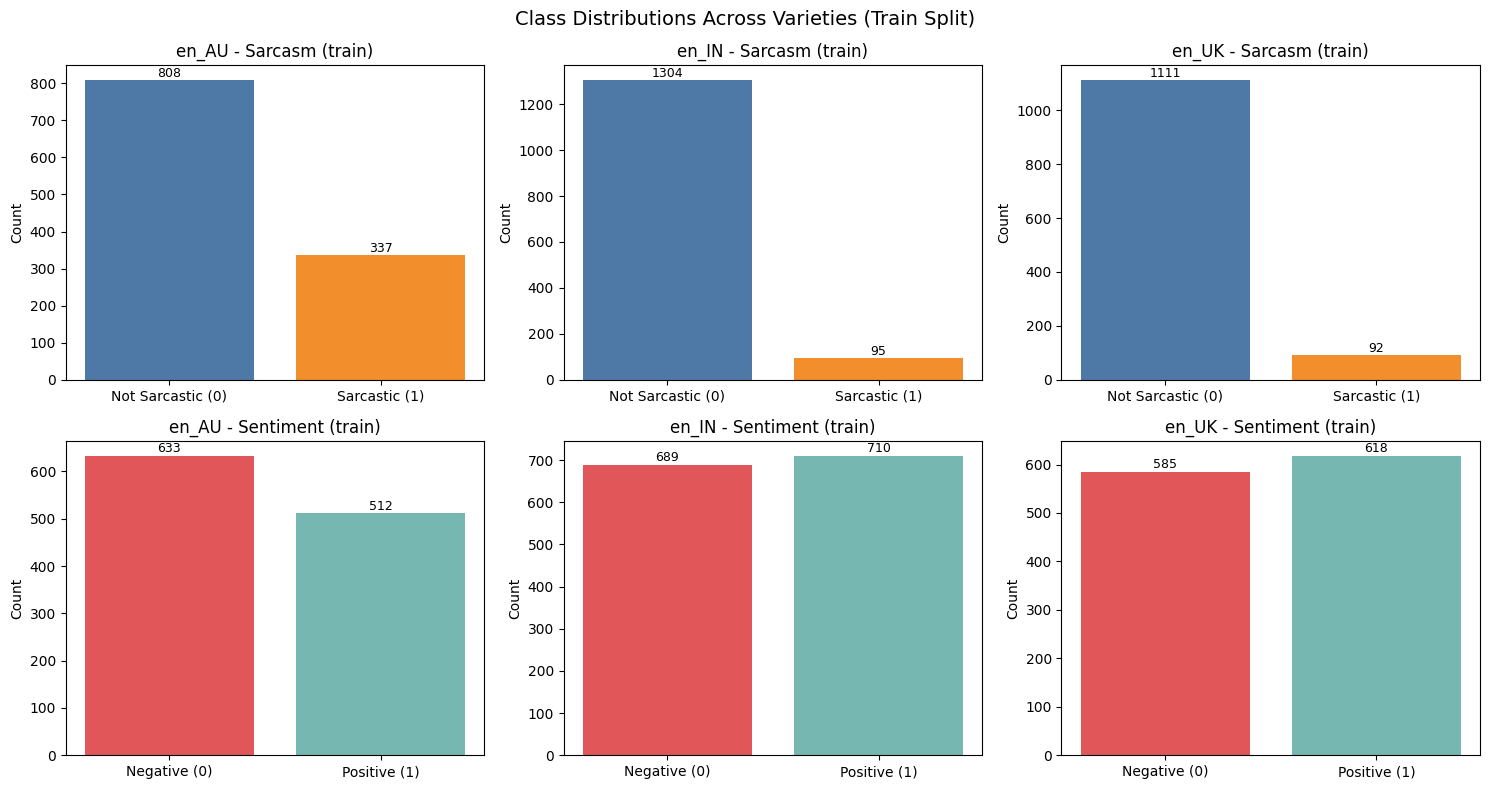

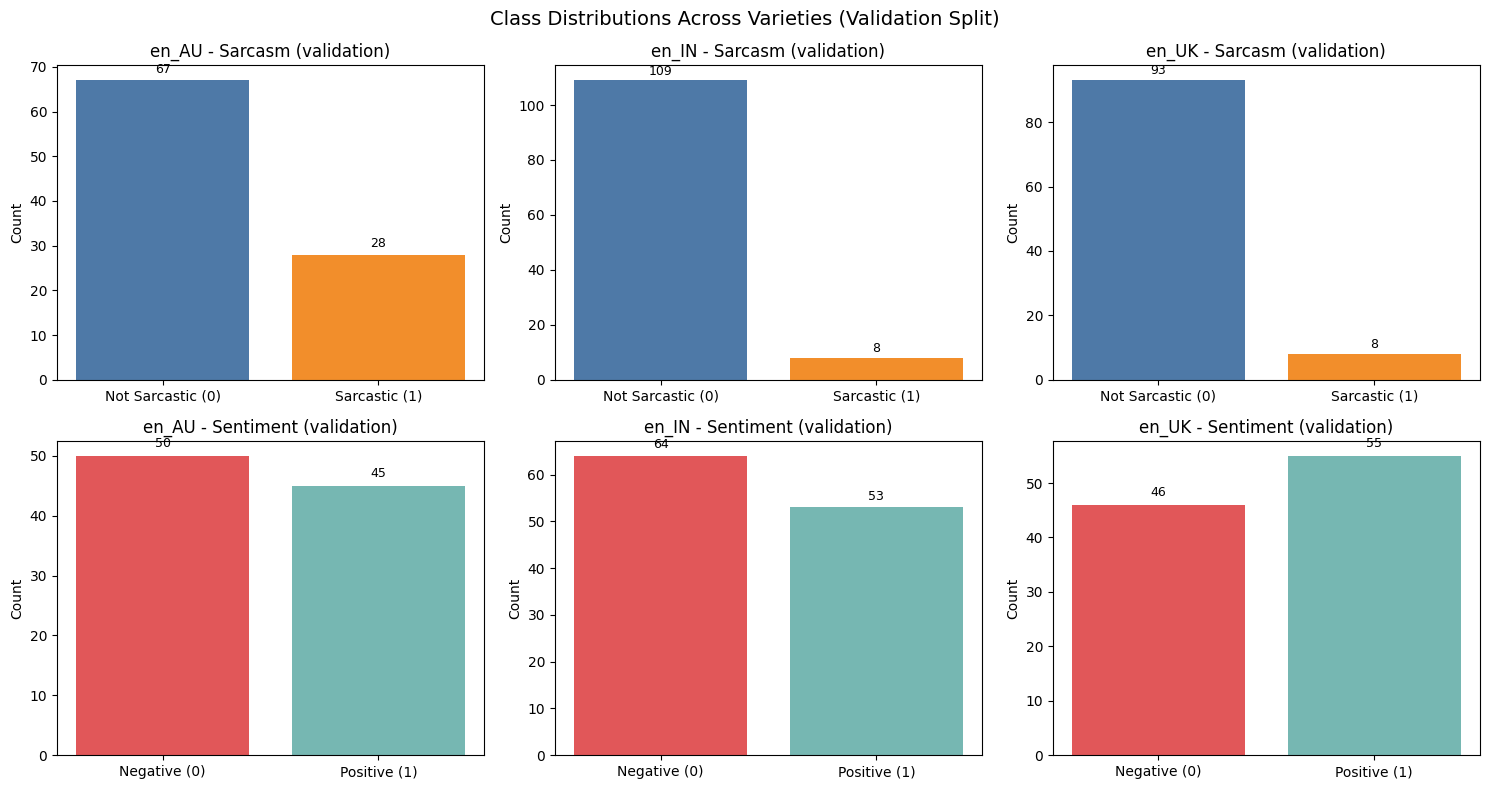

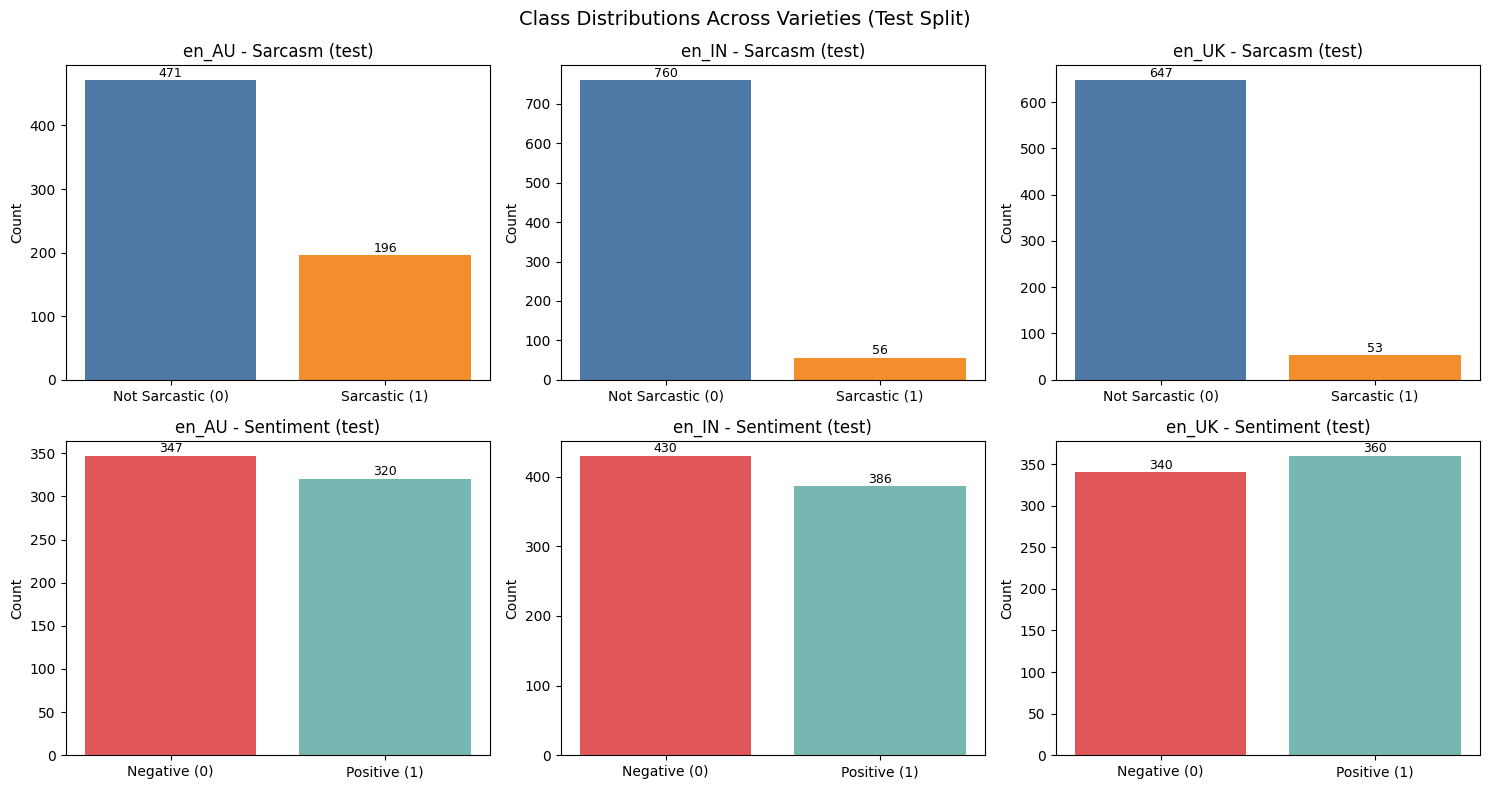

Sarcasm imbalance ratios (Not Sarcastic / Sarcastic) by split:
  [train]
    en_AU: 2.40
    en_IN: 13.73
    en_UK: 12.08
  [validation]
    en_AU: 2.39
    en_IN: 13.62
    en_UK: 11.62
  [test]
    en_AU: 2.40
    en_IN: 13.57
    en_UK: 12.21


In [4]:
for split in ['train', 'validation', 'test']:
    fig, axes = plt.subplots(2, len(varieties), figsize=(5 * len(varieties), 8))
    if len(varieties) == 1:
        axes = axes.reshape(2, 1)

    for i, v in enumerate(varieties):
        df = data[v].get(split, pd.DataFrame())
        if df.empty:
            continue

        sarc  = df['Sarcasm'].value_counts().sort_index()
        sent  = df['Sentiment'].value_counts().sort_index()

        sarc_vals = [sarc.get(0.0, 0), sarc.get(1.0, 0)]
        sent_vals = [sent.get(0.0, 0), sent.get(1.0, 0)]

        axes[0, i].bar(['Not Sarcastic (0)', 'Sarcastic (1)'], sarc_vals, color=['#4e79a7', '#f28e2b'])
        axes[0, i].set_title(f'{v} - Sarcasm ({split})')
        axes[0, i].set_ylabel('Count')
        for bar, cnt in zip(axes[0, i].patches, sarc_vals):
            axes[0, i].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                            str(cnt), ha='center', va='bottom', fontsize=9)

        axes[1, i].bar(['Negative (0)', 'Positive (1)'], sent_vals, color=['#e15759', '#76b7b2'])
        axes[1, i].set_title(f'{v} - Sentiment ({split})')
        axes[1, i].set_ylabel('Count')
        for bar, cnt in zip(axes[1, i].patches, sent_vals):
            axes[1, i].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                            str(cnt), ha='center', va='bottom', fontsize=9)

    plt.suptitle(f'Class Distributions Across Varieties ({split.capitalize()} Split)', fontsize=14)
    plt.tight_layout()
    plt.savefig(f'distributions_{split}.png', dpi=150, bbox_inches='tight')
    plt.show()

print('Sarcasm imbalance ratios (Not Sarcastic / Sarcastic) by split:')
for split in ['train', 'validation', 'test']:
    print(f'  [{split}]')
    for v in varieties:
        df = data[v].get(split, pd.DataFrame())
        if df.empty:
            continue
        c = df['Sarcasm'].value_counts()
        ratio = c.get(0.0, 0) / max(c.get(1.0, 1), 1)
        print(f'    {v}: {ratio:.2f}')

Pairwise TF-IDF Cosine Similarity (train split):
  en_AU vs en_IN: cosine=0.9522, jaccard=0.2177  (shared=3867, union=17762)
  en_AU vs en_UK: cosine=0.9856, jaccard=0.2576  (shared=4627, union=17960)
  en_IN vs en_UK: cosine=0.9463, jaccard=0.2244  (shared=3830, union=17064)


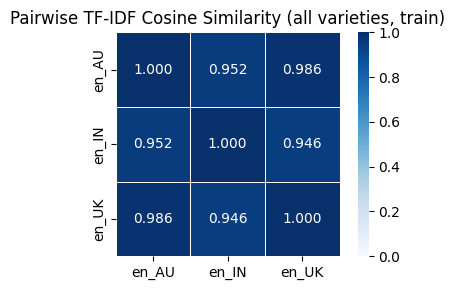

Distinctive en_AU tokens: ['be', 'have', 'not', 'they', 'we', 'are', 'with', 'on', 'but', 'you', 'that', 'for', 'was', 'is', 'in', 'it', 'of', 'to', 'and', 'the']
Distinctive en_IN tokens: ['very', 'that', 'they', 'not', 'you', 'food', 'but', 'with', 'this', 'are', 'was', 'for', 'good', 'it', 'in', 'of', 'to', 'is', 'and', 'the']
Distinctive en_UK tokens: ['you', 'food', 'were', 'they', 'not', 'this', 'on', 'that', 'but', 'we', 'with', 'is', 'in', 'for', 'it', 'of', 'was', 'to', 'and', 'the']


In [5]:
from itertools import combinations

variety_texts = {v: ' '.join(data[v]['train']['text'].tolist()) for v in varieties}

tfidf_doc = TfidfVectorizer(max_features=10000)
tfidf_doc.fit(list(variety_texts.values()))

print('Pairwise TF-IDF Cosine Similarity (train split):')
pairs = list(combinations(varieties, 2))
sim_matrix = {v: {} for v in varieties}
for va, vb in pairs:
    mat = tfidf_doc.transform([variety_texts[va], variety_texts[vb]])
    cos_sim = cosine_similarity(mat[0:1], mat[1:2])[0][0]
    vocab_a = set(variety_texts[va].lower().split())
    vocab_b = set(variety_texts[vb].lower().split())
    jaccard = len(vocab_a & vocab_b) / len(vocab_a | vocab_b)
    sim_matrix[va][vb] = cos_sim
    sim_matrix[vb][va] = cos_sim
    print(f'  {va} vs {vb}: cosine={cos_sim:.4f}, jaccard={jaccard:.4f}  '
          f'(shared={len(vocab_a & vocab_b)}, union={len(vocab_a | vocab_b)})')

# Heatmap of pairwise cosine similarity
sim_df = pd.DataFrame(sim_matrix).reindex(index=varieties, columns=varieties).fillna(1.0)
fig, ax = plt.subplots(figsize=(max(4, len(varieties)), max(3, len(varieties)-1)))
sns.heatmap(sim_df, annot=True, fmt='.3f', cmap='Blues', vmin=0, vmax=1, ax=ax,
            linewidths=0.5, square=True)
ax.set_title('Pairwise TF-IDF Cosine Similarity (all varieties, train)')
plt.tight_layout()
plt.savefig('variety_similarity.png', dpi=150, bbox_inches='tight')
plt.show()

# Most distinctive tokens per variety (vs pooled others)
tfidf_w = TfidfVectorizer(max_features=8000, min_df=2)
all_texts_list = [variety_texts[v] for v in varieties]
mat_w = tfidf_w.fit_transform(all_texts_list)
feat = tfidf_w.get_feature_names_out()
for idx, v in enumerate(varieties):
    top_v = [feat[j] for j in mat_w[idx].toarray().argsort()[0][-20:]]
    print(f'Distinctive {v} tokens: {top_v}')

v_inner = 'en_UK' if 'en_UK' in varieties else varieties[0]
v_outer = 'en_IN' if 'en_IN' in varieties else varieties[-1]

### Linguistic Distance



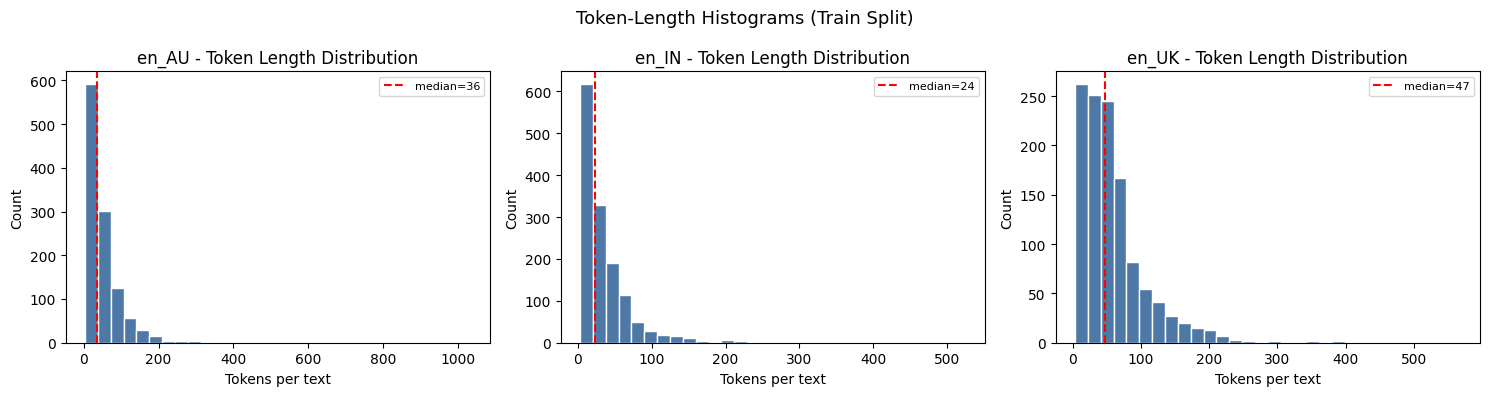

Token-length stats per variety (train split):
  en_AU: mean=55.2, median=36, std=74.7, max=1035
  en_IN: mean=36.2, median=24, std=40.2, max=525
  en_UK: mean=60.9, median=47, std=57.4, max=569

Domain (source) distribution per variety (train split):
  en_AU: {'Reddit': 756, 'Google': 389}
  en_IN: {'Google': 716, 'Reddit': 683}
  en_UK: {'Google': 769, 'Reddit': 434}


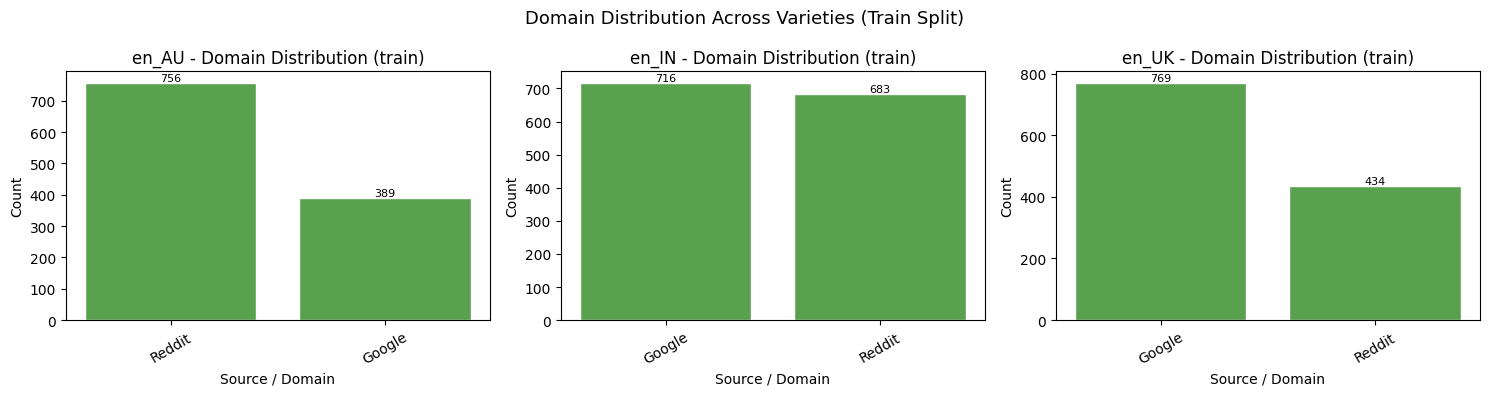


Linguistic feature analysis (train split):
  en_AU: 8/1145 texts contain variety-specific slang (0.7%)
    avg sentences per text: 4.68
    non-ASCII char ratio: 0.0000
    avg "!" per text: 0.148  |  avg "?" per text: 0.185
  en_IN: 25/1399 texts contain variety-specific slang (1.8%)
    avg sentences per text: 3.80
    non-ASCII char ratio: 0.0000
    avg "!" per text: 0.104  |  avg "?" per text: 0.112
  en_UK: 24/1203 texts contain variety-specific slang (2.0%)
    avg sentences per text: 5.16
    non-ASCII char ratio: 0.0000
    avg "!" per text: 0.323  |  avg "?" per text: 0.137


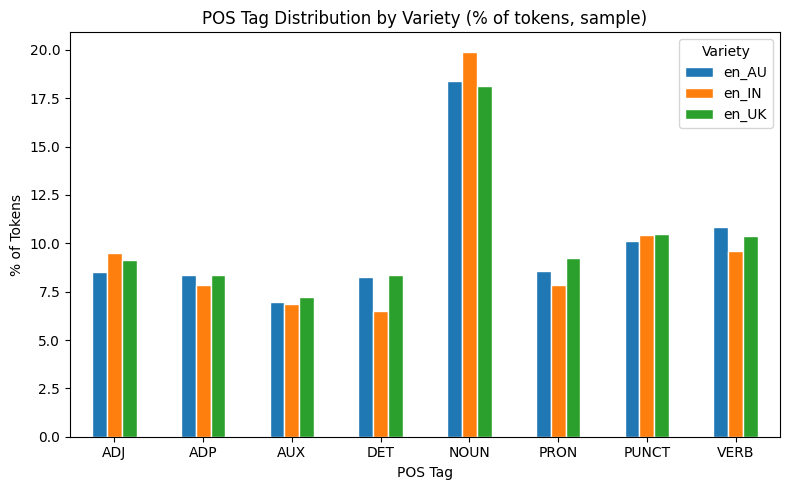


Top dependency relations per variety (train sample):
  en_AU: {'punct': 1162, 'nsubj': 981, 'det': 922, 'prep': 864, 'pobj': 816}
  en_IN: {'punct': 875, 'nsubj': 733, 'ROOT': 611, 'prep': 606, 'pobj': 579}
  en_UK: {'punct': 1551, 'nsubj': 1296, 'det': 1213, 'prep': 1120, 'pobj': 1056}

Noun-to-Verb ratio per variety (higher = more nominal style):
  en_AU: 1.70
  en_IN: 2.08
  en_UK: 1.75


In [6]:
import re

fig, axes = plt.subplots(1, len(varieties), figsize=(5 * len(varieties), 4), sharey=False)
for i, v in enumerate(varieties):
    df = data[v]['train']
    token_lens = df['text'].str.split().apply(len)
    axes[i].hist(token_lens, bins=30, color='#4e79a7', edgecolor='white')
    axes[i].set_title(f'{v} - Token Length Distribution')
    axes[i].set_xlabel('Tokens per text')
    axes[i].set_ylabel('Count')
    med = token_lens.median()
    axes[i].axvline(med, color='red', linestyle='--', label=f'median={med:.0f}')
    axes[i].legend(fontsize=8)
plt.suptitle('Token-Length Histograms (Train Split)', fontsize=13)
plt.tight_layout()
plt.savefig('token_lengths.png', dpi=150, bbox_inches='tight')
plt.show()

print('Token-length stats per variety (train split):')
for v in varieties:
    df = data[v]['train']
    tl = df['text'].str.split().apply(len)
    print(f'  {v}: mean={tl.mean():.1f}, median={tl.median():.0f}, std={tl.std():.1f}, max={tl.max()}')

print('\nDomain (source) distribution per variety (train split):')
_has_source = any('source' in data[v]['train'].columns for v in varieties)
if _has_source:
    _n_vars = len(varieties)
    _fig_d, _axes_d = plt.subplots(1, _n_vars, figsize=(5 * _n_vars, 4), sharey=False)
    if _n_vars == 1:
        _axes_d = [_axes_d]
    for _i, v in enumerate(varieties):
        df = data[v]['train']
        if 'source' in df.columns:
            srcs = df['source'].value_counts()
            print(f'  {v}: {srcs.to_dict()}')
            _axes_d[_i].bar(srcs.index, srcs.values, color='#59a14f', edgecolor='white')
            _axes_d[_i].set_title(f'{v} - Domain Distribution (train)')
            _axes_d[_i].set_xlabel('Source / Domain')
            _axes_d[_i].set_ylabel('Count')
            _axes_d[_i].tick_params(axis='x', rotation=30)
            for bar, cnt in zip(_axes_d[_i].patches, srcs.values):
                _axes_d[_i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                                  str(cnt), ha='center', va='bottom', fontsize=8)
    plt.suptitle('Domain Distribution Across Varieties (Train Split)', fontsize=13)
    plt.tight_layout()
    plt.savefig('domain_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('  (no "source" column found in any variety)')

slang_au = re.compile(r'\b(arvo|servo|maccas|strewth|crikey|reckon|ute|brekky|chrissie|garbo)\b', re.I)
slang_in = re.compile(r'\b(yaar|bhai|baap|desi|chai|jugaad|achha|chal|nahi|wala|matlab|theek|phir)\b', re.I)
slang_uk = re.compile(r'\b(brilliant|cheers|bloke|knackered|quid|loo|fortnight|rubbish|biscuit|cheeky)\b', re.I)
slang_map = {'en_AU': slang_au, 'en_IN': slang_in, 'en_UK': slang_uk}

print('\nLinguistic feature analysis (train split):')
for v in varieties:
    df = data[v]['train']
    pat = slang_map.get(v)
    if pat:
        hits = df['text'].apply(lambda t: len(pat.findall(t)))
        n_slang = (hits > 0).sum()
        print(f'  {v}: {n_slang}/{len(df)} texts contain variety-specific slang ({n_slang/len(df)*100:.1f}%)')
    avg_sents = df['text'].apply(lambda t: max(1, len(re.split(r'[.!?]+', t)))).mean()
    print(f'    avg sentences per text: {avg_sents:.2f}')
    non_ascii = df['text'].apply(lambda t: sum(1 for c in t if ord(c) > 127) / max(len(t), 1))
    print(f'    non-ASCII char ratio: {non_ascii.mean():.4f}')
    excl = df['text'].str.count('!').mean()
    qmark = df['text'].str.count(r'\?').mean()
    print(f'    avg "!" per text: {excl:.3f}  |  avg "?" per text: {qmark:.3f}')

# POS tagging & basic dependency analysis using spaCy
try:
    import spacy
    _nlp = spacy.load('en_core_web_sm', disable=['ner', 'lemmatizer'])
    _sample_n = 200

    pos_rows = []
    for v in varieties:
        df = data[v]['train'].sample(min(_sample_n, len(data[v]['train'])), random_state=42)
        for doc in _nlp.pipe(df['text'].tolist(), batch_size=32):
            for tok in doc:
                if not tok.is_space:
                    pos_rows.append({'variety': v, 'pos': tok.pos_, 'dep': tok.dep_})

    pos_df = pd.DataFrame(pos_rows)

    pos_pct = (
        pos_df.groupby(['variety', 'pos'])
        .size()
        .groupby(level=0, group_keys=False)
        .apply(lambda s: s / s.sum() * 100)
        .rename('pct')
        .reset_index()
    )
    top_pos = pos_df['pos'].value_counts().head(8).index.tolist()
    pos_pivot = pos_pct[pos_pct['pos'].isin(top_pos)].pivot(index='pos', columns='variety', values='pct').fillna(0)

    fig_pos, ax_pos = plt.subplots(figsize=(max(8, len(varieties)*2), 5))
    pos_pivot.plot(kind='bar', ax=ax_pos, edgecolor='white')
    ax_pos.set_title('POS Tag Distribution by Variety (% of tokens, sample)')
    ax_pos.set_xlabel('POS Tag')
    ax_pos.set_ylabel('% of Tokens')
    ax_pos.legend(title='Variety')
    ax_pos.tick_params(axis='x', rotation=0)
    plt.tight_layout()
    plt.savefig('pos_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()

    print('\nTop dependency relations per variety (train sample):')
    for v in varieties:
        deps = pos_df[pos_df['variety'] == v]['dep'].value_counts().head(5)
        print(f'  {v}: {deps.to_dict()}')

    print('\nNoun-to-Verb ratio per variety (higher = more nominal style):')
    for v in varieties:
        sub = pos_df[pos_df['variety'] == v]
        n_nouns = (sub['pos'] == 'NOUN').sum()
        n_verbs = (sub['pos'] == 'VERB').sum()
        print(f'  {v}: {n_nouns/max(n_verbs,1):.2f}')

except OSError:
    print("spaCy model not found - run: python -m spacy download en_core_web_sm")
except ImportError:
    print("spaCy not installed - run: pip install spacy")

---
## Section 2.1: Baseline / PTLM Gap - with Class Imbalance Interventions

Classical baselines - six experiments:
1. TF-IDF (word 1-2g) + LR (class_weight='balanced')
2. TF-IDF (word 1-2g) + LinearSVC (class_weight='balanced')
3. TF-IDF (word+char+hand) + LR - feature-engineered baseline
4. TF-IDF (word) + ComplementNB - imbalance-aware NB
5. SMOTE + TF-IDF (word) + LR - synthetic minority oversampling before training 
6. EDA Augmentation + TF-IDF (word) + LR - synonym-replacement augmentation of sarcastic texts 

PTLM - four RoBERTa runs:
- Runs 1-2: standard cross-entropy (ablation)
- Run 3: class-weighted CE 
- Run 4: Focal Loss (gamma=2) - down-weights easy negatives, forces focus on hard sarcastic cases 



In [7]:
from sklearn.naive_bayes import ComplementNB
from scipy.sparse import hstack, csr_matrix
from imblearn.over_sampling import SMOTE
import re
import nltk
from nltk.corpus import wordnet

nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

all_train = pd.concat([data[v]['train']      for v in varieties], ignore_index=True)
all_val   = pd.concat([data[v]['validation'] for v in varieties], ignore_index=True)
all_test  = pd.concat([data[v]['test']       for v in varieties], ignore_index=True)

_pos_re = re.compile(r'great|amazing|brilliant|wonderful|perfect|excellent', re.I)

def extract_ling_features(df):
    t = df['text']
    return np.column_stack([
        t.str.count('!').values,
        t.str.count(r'\?').values,
        t.apply(lambda s: sum(c.isupper() for c in s) / max(len(s), 1)).values,
        t.str.split().apply(len).values,
        t.str.count(r'[\u201c\u201d"]').values,
        t.str.count(r'\.{2,}').values,
        t.apply(lambda s: len(_pos_re.findall(s))).values,
    ])

def synonym_replace(text, n=2):
    words = text.split()
    new_words = words.copy()
    replaced = 0
    for i, w in enumerate(words):
        if replaced >= n:
            break
        syns = wordnet.synsets(w)
        if not syns:
            continue
        lemmas = [l.name().replace('_', ' ')
                  for l in syns[0].lemmas() if l.name().lower() != w.lower()]
        if lemmas:
            new_words[i] = lemmas[0]
            replaced += 1
    return ' '.join(new_words)

def eda_augment(df, task='Sarcasm', n_aug=2):
    minority = df[df[task] == 1].copy()
    augmented_rows = []
    for _, row in minority.iterrows():
        for _ in range(n_aug):
            new_row = row.copy()
            new_row['text'] = synonym_replace(row['text'])
            augmented_rows.append(new_row)
    aug_df = pd.DataFrame(augmented_rows)
    return pd.concat([df, aug_df], ignore_index=True).sample(
        frac=1, random_state=42).reset_index(drop=True)

tfidf_word = TfidfVectorizer(max_features=20000, ngram_range=(1, 2), sublinear_tf=True)
tfidf_char = TfidfVectorizer(max_features=10000, ngram_range=(2, 4),
                              analyzer='char_wb', sublinear_tf=True)

X_word_tr = tfidf_word.fit_transform(all_train['text'])
X_char_tr = tfidf_char.fit_transform(all_train['text'])
X_hand_tr = csr_matrix(extract_ling_features(all_train))

X_word_te = tfidf_word.transform(all_test['text'])
X_char_te = tfidf_char.transform(all_test['text'])
X_hand_te = csr_matrix(extract_ling_features(all_test))

X_tr_comb = hstack([X_word_tr, X_char_tr, X_hand_tr])
X_te_comb = hstack([X_word_te, X_char_te, X_hand_te])

tfidf = tfidf_word

baseline_results = {}

for task in ['Sentiment', 'Sarcasm']:
    y_tr = all_train[task].astype(int).values
    y_te = all_test[task].astype(int).values

    print(f'\nTask: {task}')

    lr = LogisticRegression(class_weight='balanced', max_iter=1000, C=1.0, random_state=42)
    lr.fit(X_word_tr, y_tr)
    preds_lr = lr.predict(X_word_te)

    svm = LinearSVC(class_weight='balanced', max_iter=2000, C=0.5, random_state=42)
    svm.fit(X_word_tr, y_tr)
    preds_svm = svm.predict(X_word_te)

    lr_comb = LogisticRegression(class_weight='balanced', max_iter=1000, C=1.0, random_state=42)
    lr_comb.fit(X_tr_comb, y_tr)
    preds_lr_comb = lr_comb.predict(X_te_comb)

    cnb = ComplementNB(alpha=0.5)
    cnb.fit(X_word_tr, y_tr)
    preds_cnb = cnb.predict(X_word_te)

    print(f'  Fitting SMOTE for {task}...')
    n_minority = (y_tr == 1).sum()
    smote = SMOTE(random_state=42, k_neighbors=min(5, n_minority - 1))
    X_sm, y_sm = smote.fit_resample(X_word_tr, y_tr)
    lr_smote = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
    lr_smote.fit(X_sm, y_sm)
    preds_smote = lr_smote.predict(X_word_te)
    unique, counts = np.unique(y_sm, return_counts=True)
    print(f'  SMOTE resampled: {dict(zip(unique.tolist(), counts.tolist()))}')

    print(f'  Running EDA augmentation for {task}...')
    train_aug = eda_augment(all_train, task=task, n_aug=2)
    X_eda_tr  = tfidf_word.transform(train_aug['text'])
    y_eda_tr  = train_aug[task].astype(int).values
    lr_eda = LogisticRegression(class_weight='balanced', max_iter=1000, C=1.0, random_state=42)
    lr_eda.fit(X_eda_tr, y_eda_tr)
    preds_eda = lr_eda.predict(X_word_te)
    print(f'  EDA train size: {len(train_aug)} (was {len(all_train)}); ' +
          f'sarcasm pos: {(y_eda_tr==1).sum()} (was {(y_tr==1).sum()})')

    for name, preds in [
        ('TF-IDF(word) + LR',           preds_lr),
        ('TF-IDF(word) + SVM',           preds_svm),
        ('TF-IDF(word+char+hand) + LR',  preds_lr_comb),
        ('ComplementNB',                  preds_cnb),
        ('SMOTE + LR',           preds_smote),
        ('EDA Augmentation + LR', preds_eda),
    ]:
        print(f'\n{name}')
        print(classification_report(y_te, preds, digits=3))

    baseline_results[task] = {
        'LR':      {'preds': preds_lr,      'true': y_te},
        'SVM':     {'preds': preds_svm,     'true': y_te},
        'LR-Comb': {'preds': preds_lr_comb, 'true': y_te},
        'CNB':     {'preds': preds_cnb,     'true': y_te},
        'SMOTE':   {'preds': preds_smote,   'true': y_te},
        'EDA':     {'preds': preds_eda,     'true': y_te},
    }

    if task == 'Sarcasm':
        print('\nPer-Variety Sarcasm Breakdown')
        print(f'{"Variety":<8} {"Model":<30} {"Macro-F1":>9} {"Precision":>10} {"Recall":>8}')
        for v in varieties:
            te_v = data[v]['test']
            y_v  = te_v['Sarcasm'].astype(int).values
            X_v  = tfidf_word.transform(te_v['text'])
            X_vc = hstack([X_v,
                            tfidf_char.transform(te_v['text']),
                            csr_matrix(extract_ling_features(te_v))])
            for nm, mdl, Xp in [
                ('LR',       lr,       X_v),
                ('SVM',      svm,      X_v),
                ('LR-Comb',  lr_comb,  X_vc),
                ('CNB',      cnb,      X_v),
                ('SMOTE+LR', lr_smote, X_v),
                ('EDA+LR',   lr_eda,   X_v),
            ]:
                p_v = mdl.predict(Xp)
                prec_v, rec_v, f1_v, _ = precision_recall_fscore_support(y_v, p_v, average='macro')
                print(f'{v:<8} {nm:<30} {f1_v:>9.3f} {prec_v:>10.3f} {rec_v:>8.3f}')

lr_sarc = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr_sarc.fit(X_word_tr, all_train['Sarcasm'].astype(int).values)


Task: Sentiment
  Fitting SMOTE for Sentiment...
  SMOTE resampled: {0: 1907, 1: 1907}
  Running EDA augmentation for Sentiment...
  EDA train size: 7427 (was 3747); sarcasm pos: 5520 (was 1840)

TF-IDF(word) + LR
              precision    recall  f1-score   support

           0      0.818     0.858     0.837      1117
           1      0.843     0.800     0.821      1066

    accuracy                          0.830      2183
   macro avg      0.830     0.829     0.829      2183
weighted avg      0.830     0.830     0.829      2183


TF-IDF(word) + SVM
              precision    recall  f1-score   support

           0      0.830     0.868     0.848      1117
           1      0.854     0.813     0.833      1066

    accuracy                          0.841      2183
   macro avg      0.842     0.840     0.841      2183
weighted avg      0.842     0.841     0.841      2183


TF-IDF(word+char+hand) + LR
              precision    recall  f1-score   support

           0      0.828    

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [8]:
import gc, torch
from sklearn.utils.class_weight import compute_class_weight as skl_cwt

gc.collect()
torch.cuda.empty_cache()

TASK = 'Sarcasm'
ROBERTA_NAME = 'roberta-base'
tok_rob = AutoTokenizer.from_pretrained(ROBERTA_NAME)

def to_hf(df, task):
    return HFDataset.from_dict({
        'text':  df['text'].tolist(),
        'label': df[task].astype(int).tolist(),
    })

def tok_fn_rob(batch):
    return tok_rob(batch['text'], truncation=True, max_length=128, padding=False)

train_ds = to_hf(all_train, TASK).map(tok_fn_rob, batched=True, remove_columns=['text'])
val_ds   = to_hf(all_val,   TASK).map(tok_fn_rob, batched=True, remove_columns=['text'])
test_ds  = to_hf(all_test,  TASK).map(tok_fn_rob, batched=True, remove_columns=['text'])
collator = DataCollatorWithPadding(tok_rob)

def metrics_fn(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {'macro_f1': f1_score(labels, preds, average='macro')}

# Class weights for weighted CE
cw_vals = skl_cwt('balanced', classes=np.array([0, 1]),
                   y=all_train[TASK].astype(int).values)
class_weights_tensor = torch.tensor(cw_vals, dtype=torch.float32)
print(f'Class weights -> Not Sarcastic: {cw_vals[0]:.3f}  |  Sarcastic: {cw_vals[1]:.3f}')
print(f'Sarcastic weighted {cw_vals[1]/cw_vals[0]:.1f}x more than non-sarcastic\n')

class WeightedLossTrainer(Trainer):
    def __init__(self, class_weights, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self._cw = class_weights
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop('labels')
        outputs = model(**inputs)
        loss = torch.nn.CrossEntropyLoss(
            weight=self._cw.to(outputs.logits.device)
        )(outputs.logits, labels)
        return (loss, outputs) if return_outputs else loss

class FocalLossTrainer(Trainer):
    def __init__(self, gamma=2.0, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.gamma = gamma
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop('labels')
        outputs = model(**inputs)
        ce = torch.nn.CrossEntropyLoss(reduction='none')(outputs.logits, labels)
        pt = torch.exp(-ce)
        focal_loss = ((1 - pt) ** self.gamma * ce).mean()
        return (focal_loss, outputs) if return_outputs else focal_loss

rob_run_configs = [
    {
        'lr': 2e-5, 'epochs': 3, 'trainer_cls': Trainer, 'extra_kwargs': {},
        'output_dir': './ci_roberta_run1',
        'label': 'Run 1 - lr=2e-5, 3ep, standard CE (baseline)',
    },
    {
        'lr': 3e-5, 'epochs': 3, 'trainer_cls': Trainer, 'extra_kwargs': {},
        'output_dir': './ci_roberta_run2',
        'label': 'Run 2 - lr=3e-5, 3ep, standard CE',
    },
    {
        'lr': 2e-5, 'epochs': 3,
        'trainer_cls': WeightedLossTrainer,
        'extra_kwargs': {'class_weights': class_weights_tensor},
        'output_dir': './ci_roberta_run3',
        'label': 'Run 3 - lr=2e-5, 3ep, Class-Weighted CE',
    },
    {
        'lr': 2e-5, 'epochs': 3,
        'trainer_cls': FocalLossTrainer,
        'extra_kwargs': {'gamma': 2.0},
        'output_dir': './ci_roberta_run4',
        'label': 'Run 4 - lr=2e-5, 3ep, Focal Loss gamma=2',
    },
]

best_f1            = -1
rob_preds          = None
run_summary        = []
val_logits_per_run = {}

for cfg in rob_run_configs:
    print(f'\n{cfg["label"]}')
    model_i = AutoModelForSequenceClassification.from_pretrained(ROBERTA_NAME, num_labels=2)
    model_i.gradient_checkpointing_enable()

    args_i = TrainingArguments(
        output_dir=cfg['output_dir'],
        num_train_epochs=cfg['epochs'],
        per_device_train_batch_size=4,
        gradient_accumulation_steps=4,
        per_device_eval_batch_size=16,
        eval_strategy='epoch',
        save_strategy='no',
        learning_rate=cfg['lr'],
        weight_decay=0.01,
        warmup_ratio=0.1,
        fp16=torch.cuda.is_available(),
        report_to='none',
        logging_steps=100,
    )
    trainer_i = cfg['trainer_cls'](
        **cfg['extra_kwargs'],
        model=model_i, args=args_i,
        train_dataset=train_ds, eval_dataset=val_ds,
        data_collator=collator, compute_metrics=metrics_fn,
    )
    trainer_i.train()

    val_out = trainer_i.predict(val_ds)
    val_logits_per_run[cfg['label']] = val_out.predictions

    out_i   = trainer_i.predict(test_ds)
    preds_i = np.argmax(out_i.predictions, axis=-1)
    f1_i    = f1_score(all_test[TASK].astype(int).values, preds_i, average='macro')
    prec_i, rec_i, _, _ = precision_recall_fscore_support(
        all_test[TASK].astype(int).values, preds_i, average='macro')

    print(classification_report(all_test[TASK].astype(int).values, preds_i, digits=3))
    run_summary.append({
        'Run':                     cfg['label'],
        'Macro-F1 (thresh=0.5)':  round(f1_i, 3),
        'Precision':              round(prec_i, 3),
        'Recall':                 round(rec_i, 3),
        'test_logits':            out_i.predictions,
    })

    if f1_i > best_f1:
        best_f1   = f1_i
        rob_preds = preds_i
        trainer_i.save_model('./roberta_best')
        print(f'  -> New best Macro-F1={f1_i:.3f} saved to ./roberta_best')

    model_i.cpu()
    del model_i, trainer_i
    gc.collect()
    torch.cuda.empty_cache()

print('\nRoBERTa Run Comparison (Sarcasm, pooled test set, threshold=0.5)')
cmp_df = pd.DataFrame([{k: v for k, v in r.items() if k != 'test_logits'} for r in run_summary])
print(cmp_df.to_string(index=False))
print(f'\nBest Macro-F1: {best_f1:.3f}')

Map: 100%|██████████| 2183/2183 [00:00<00:00, 11686.85 examples/s]


Class weights -> Not Sarcastic: 0.581  |  Sarcastic: 3.575
Sarcastic weighted 6.2x more than non-sarcastic


Run 1 - lr=2e-5, 3ep, standard CE (baseline)


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Macro F1
1,0.325100,0.317562,0.526168
2,0.291200,0.377325,0.640643
3,0.228600,0.342685,0.653542


              precision    recall  f1-score   support

           0      0.893     0.961     0.926      1878
           1      0.549     0.292     0.381       305

    accuracy                          0.868      2183
   macro avg      0.721     0.626     0.654      2183
weighted avg      0.845     0.868     0.850      2183

  -> New best Macro-F1=0.654 saved to ./roberta_best

Run 2 - lr=3e-5, 3ep, standard CE


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Macro F1
1,0.392300,0.435034,0.462199
2,0.376800,0.484401,0.462199
3,0.346800,0.388838,0.462199


              precision    recall  f1-score   support

           0      0.860     1.000     0.925      1878
           1      0.000     0.000     0.000       305

    accuracy                          0.860      2183
   macro avg      0.430     0.500     0.462      2183
weighted avg      0.740     0.860     0.796      2183


Run 3 - lr=2e-5, 3ep, Class-Weighted CE


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Macro F1
1,0.501800,0.488457,0.667668
2,0.457800,0.804971,0.640077
3,0.353200,0.681209,0.666757


              precision    recall  f1-score   support

           0      0.911     0.926     0.918      1878
           1      0.493     0.443     0.466       305

    accuracy                          0.858      2183
   macro avg      0.702     0.684     0.692      2183
weighted avg      0.853     0.858     0.855      2183

  -> New best Macro-F1=0.692 saved to ./roberta_best

Run 4 - lr=2e-5, 3ep, Focal Loss gamma=2


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Macro F1
1,0.090700,0.086126,0.616387
2,0.078000,0.121899,0.640643
3,0.059100,0.098822,0.640643


              precision    recall  f1-score   support

           0      0.894     0.967     0.929      1878
           1      0.592     0.295     0.394       305

    accuracy                          0.873      2183
   macro avg      0.743     0.631     0.662      2183
weighted avg      0.852     0.873     0.854      2183


RoBERTa Run Comparison (Sarcasm, pooled test set, threshold=0.5)
                                         Run  Macro-F1 (thresh=0.5)  Precision  Recall
Run 1 - lr=2e-5, 3ep, standard CE (baseline)                  0.654      0.721   0.626
           Run 2 - lr=3e-5, 3ep, standard CE                  0.462      0.430   0.500
     Run 3 - lr=2e-5, 3ep, Class-Weighted CE                  0.692      0.702   0.684
    Run 4 - lr=2e-5, 3ep, Focal Loss gamma=2                  0.662      0.743   0.631

Best Macro-F1: 0.692


Threshold Moving Results (Sarcasm, pooled test set)
                                         Run  Default F1  Optimal Thresh  Val F1 @opt  Test F1 @opt  Prec @opt  Recall @opt  F1 Delta
Run 1 - lr=2e-5, 3ep, standard CE (baseline)       0.654            0.05        0.693         0.688      0.667        0.783     0.034
           Run 2 - lr=3e-5, 3ep, standard CE       0.462            0.05        0.626         0.604      0.617        0.731     0.142
     Run 3 - lr=2e-5, 3ep, Class-Weighted CE       0.692            0.13        0.693         0.685      0.664        0.768    -0.007
    Run 4 - lr=2e-5, 3ep, Focal Loss gamma=2       0.662            0.21        0.715         0.671      0.654        0.764     0.009


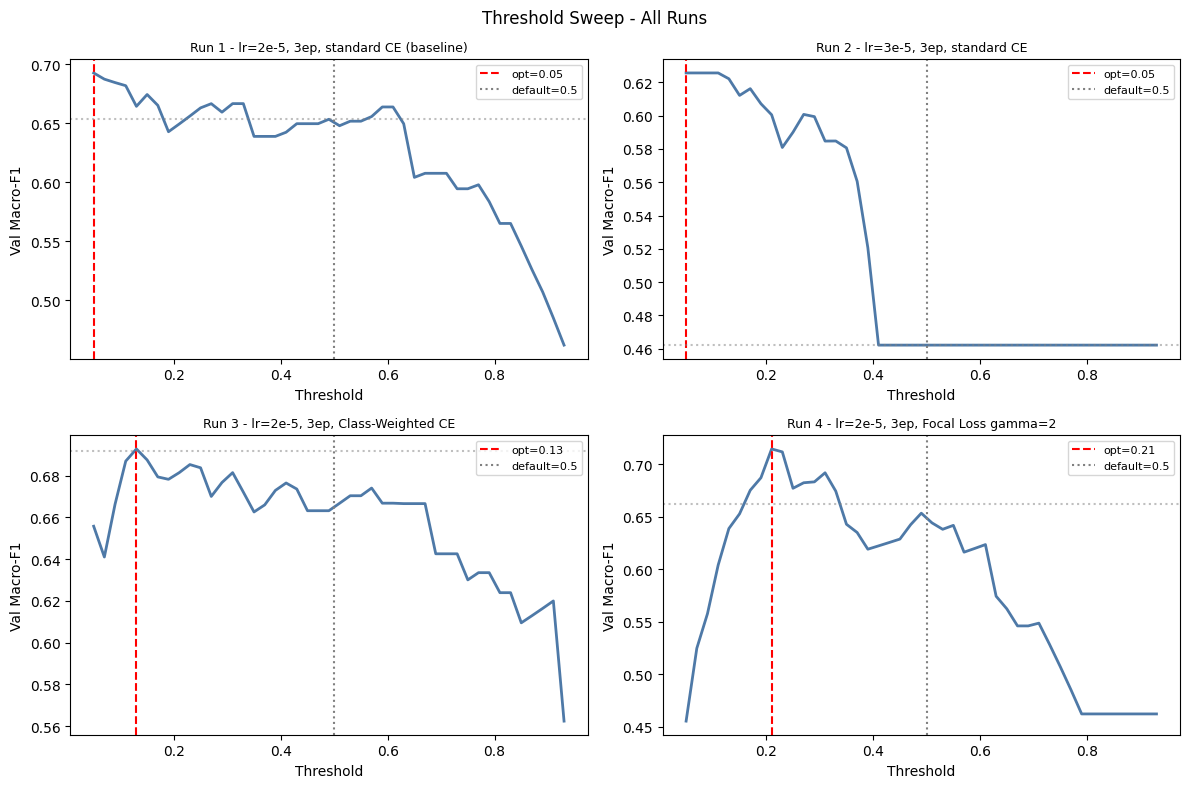


rob_preds updated: using threshold 0.05 from best run.


In [9]:

from scipy.special import softmax as sp_softmax

y_val_true  = all_val[TASK].astype(int).values
y_test_true = all_test[TASK].astype(int).values

threshold_results = []

for run_info in run_summary:
    label = run_info['Run']
    val_probs  = sp_softmax(val_logits_per_run[label],   axis=1)[:, 1]
    test_probs = sp_softmax(run_info['test_logits'],      axis=1)[:, 1]

    best_t, best_val_f1 = 0.5, 0.0
    for t in np.arange(0.05, 0.95, 0.02):
        vf1 = f1_score(y_val_true, (val_probs >= t).astype(int), average='macro')
        if vf1 > best_val_f1:
            best_val_f1, best_t = vf1, round(float(t), 2)

    test_preds_opt = (test_probs >= best_t).astype(int)
    test_f1_opt    = f1_score(y_test_true, test_preds_opt, average='macro')
    prec_opt, rec_opt, _, _ = precision_recall_fscore_support(
        y_test_true, test_preds_opt, average='macro')

    threshold_results.append({
        'Run':            label,
        'Default F1':     run_info['Macro-F1 (thresh=0.5)'],
        'Optimal Thresh': best_t,
        'Val F1 @opt':    round(best_val_f1, 3),
        'Test F1 @opt':   round(test_f1_opt, 3),
        'Prec @opt':      round(prec_opt, 3),
        'Recall @opt':    round(rec_opt, 3),
        'F1 Delta':       round(test_f1_opt - run_info['Macro-F1 (thresh=0.5)'], 3),
    })

thr_df = pd.DataFrame(threshold_results)
print('Threshold Moving Results (Sarcasm, pooled test set)')
print('=' * 80)
print(thr_df.to_string(index=False))

thresholds = np.arange(0.05, 0.95, 0.02)
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, run_info, res in zip(axes, run_summary, threshold_results):
    label = run_info['Run']
    val_probs = sp_softmax(val_logits_per_run[label], axis=1)[:, 1]
    val_f1s = [f1_score(y_val_true, (val_probs >= t).astype(int), average='macro')
               for t in thresholds]
    ax.plot(thresholds, val_f1s, lw=2, color='#4e79a7')
    ax.axvline(res['Optimal Thresh'], color='red', linestyle='--',
               label=f'opt={res["Optimal Thresh"]}')
    ax.axvline(0.5, color='gray', linestyle=':', label='default=0.5')
    ax.axhline(res['Default F1'], color='gray', linestyle=':', alpha=0.5)
    ax.set_title(label[:50], fontsize=9)
    ax.set_xlabel('Threshold')
    ax.set_ylabel('Val Macro-F1')
    ax.legend(fontsize=8)

plt.suptitle('Threshold Sweep - All Runs', fontsize=12)
plt.tight_layout()
plt.savefig('threshold_sweep.png', dpi=150)
plt.show()

best_thr_row = max(threshold_results, key=lambda x: x['Test F1 @opt'])

best_run_label  = best_thr_row['Run']
best_run_logits = next(r['test_logits'] for r in run_summary if r['Run'] == best_run_label)
best_run_probs  = sp_softmax(best_run_logits, axis=1)[:, 1]
rob_preds = (best_run_probs >= best_thr_row['Optimal Thresh']).astype(int)
print(f'\nrob_preds updated: using threshold {best_thr_row["Optimal Thresh"]} from best run.')

### Section 2.1 - Findings Summary (Class Imbalance Edition)



---
## Section 2.2: Cross-Variety Evaluation

RoBERTa-base fine-tuned separately on each variety, then evaluated on all three test sets. Produces a 3×3 Macro-F1 matrix.

GPU free after cleanup: 3.53 GiB
Training on en_AU...


Map: 100%|██████████| 95/95 [00:00<00:00, 4456.79 examples/s]
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Macro F1
1,No log,0.525488,0.712702
2,0.533400,0.457861,0.767840


Map: 100%|██████████| 667/667 [00:00<00:00, 9614.24 examples/s]


Map: 100%|██████████| 816/816 [00:00<00:00, 12008.03 examples/s]


Map: 100%|██████████| 700/700 [00:00<00:00, 10224.02 examples/s]


  {'en_AU': 0.755, 'en_IN': 0.5, 'en_UK': 0.612}
Training on en_IN...


Map: 100%|██████████| 117/117 [00:00<00:00, 9582.21 examples/s]
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Macro F1
1,No log,0.508265,0.607646
2,0.500100,0.669079,0.633484


Map: 100%|██████████| 667/667 [00:00<00:00, 10482.30 examples/s]


Map: 100%|██████████| 816/816 [00:00<00:00, 14486.93 examples/s]


Map: 100%|██████████| 700/700 [00:00<00:00, 10638.88 examples/s]


  {'en_AU': 0.458, 'en_IN': 0.503, 'en_UK': 0.549}
Training on en_UK...


Map: 100%|██████████| 101/101 [00:00<00:00, 6952.19 examples/s]
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Macro F1
1,No log,0.992012,0.479381
2,0.464200,0.875399,0.479381


Map: 100%|██████████| 667/667 [00:00<00:00, 9996.43 examples/s]


Map: 100%|██████████| 816/816 [00:00<00:00, 15027.01 examples/s]


Map: 100%|██████████| 700/700 [00:00<00:00, 9518.94 examples/s]


  {'en_AU': 0.414, 'en_IN': 0.482, 'en_UK': 0.48}
               en_AU  en_IN  en_UK
Train \\ Test                     
en_AU          0.755  0.500  0.612
en_IN          0.458  0.503  0.549
en_UK          0.414  0.482  0.480


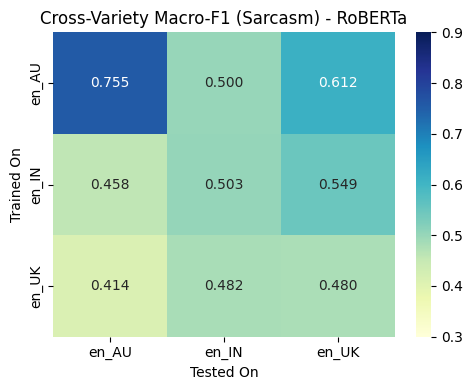

In [10]:
from sklearn.utils.class_weight import compute_class_weight

import gc

for _name in ('trainer_rob', 'model_rob'):
    if _name in vars():
        obj = vars()[_name]
        if hasattr(obj, 'model'):
            obj.model.cpu()
        elif hasattr(obj, 'cpu'):
            obj.cpu()
        del obj
        exec(f'del {_name}')
gc.collect()
torch.cuda.empty_cache()
print(f'GPU free after cleanup: {torch.cuda.mem_get_info()[0]/1024**3:.2f} GiB')

def train_variety_roberta(variety, task=TASK, epochs=2):
    ds_tr = to_hf(data[variety]['train'], task).map(tok_fn_rob, batched=True, remove_columns=['text'])
    ds_va = to_hf(data[variety]['validation'], task).map(tok_fn_rob, batched=True, remove_columns=['text'])
    model = AutoModelForSequenceClassification.from_pretrained(ROBERTA_NAME, num_labels=2)
    model.gradient_checkpointing_enable()

    cw = compute_class_weight('balanced',
                              classes=np.array([0, 1]),
                              y=data[variety]['train'][task].astype(int).values)
    cw_tensor = torch.tensor(cw, dtype=torch.float32)

    args = TrainingArguments(
        output_dir=f'./cv_{variety}',
        num_train_epochs=epochs,
        per_device_train_batch_size=4,
        gradient_accumulation_steps=4,
        per_device_eval_batch_size=16,
        eval_strategy='epoch',
        save_strategy='no',
        learning_rate=2e-5,
        fp16=torch.cuda.is_available(),
        report_to='none',
        logging_steps=100,
    )
    trainer = WeightedLossTrainer(
        class_weights=cw_tensor,
        model=model, args=args,
        train_dataset=ds_tr, eval_dataset=ds_va,
        data_collator=collator, compute_metrics=metrics_fn,
    )
    trainer.train()
    return trainer

cross_f1 = {}
for train_v in varieties:
    print(f'Training on {train_v}...')
    t = train_variety_roberta(train_v)
    cross_f1[train_v] = {}
    for test_v in varieties:
        ds_te = to_hf(data[test_v]['test'], TASK).map(tok_fn_rob, batched=True, remove_columns=['text'])
        out   = t.predict(ds_te)
        preds = np.argmax(out.predictions, axis=-1)
        cross_f1[train_v][test_v] = round(
            f1_score(data[test_v]['test'][TASK].values, preds, average='macro'), 3
        )
    print(f'  {cross_f1[train_v]}')

    t.model.cpu()
    del t
    gc.collect()
    torch.cuda.empty_cache()

cross_df = pd.DataFrame(cross_f1).T
cross_df.index.name = 'Train \\\\ Test'
print(cross_df.to_string())

plt.figure(figsize=(5, 4))
sns.heatmap(cross_df.astype(float), annot=True, fmt='.3f', cmap='YlGnBu', vmin=0.3, vmax=0.9)
plt.title(f'Cross-Variety Macro-F1 ({TASK}) - RoBERTa')
plt.ylabel('Trained On')
plt.xlabel('Tested On')
plt.tight_layout()
plt.savefig('cross_variety.png', dpi=150)
plt.show()

model_rob = AutoModelForSequenceClassification.from_pretrained('./roberta_best')

---
## Section 2.3: LLM Variations - LoRA Adapters

TinyLlama-1.1B with Low-Rank Adaptation (LoRA). One adapter per variety (UK and IN) for the sarcasm task. Same frozen base model; only adapter weights differ.

In [11]:
LORA_BASE = 'TinyLlama/TinyLlama-1.1B-Chat-v1.0'
tok_lora = AutoTokenizer.from_pretrained(LORA_BASE)
if tok_lora.pad_token is None:
    tok_lora.pad_token    = tok_lora.eos_token
    tok_lora.pad_token_id = tok_lora.eos_token_id

def tok_fn_lora(batch):
    return tok_lora(batch['text'], truncation=True, max_length=128, padding=False)

lora_cfg = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=8,
    lora_alpha=16,
    lora_dropout=0.1,
    target_modules=['q_proj', 'k_proj', 'v_proj'],
    bias='none',
)

def train_lora(variety, task='Sarcasm', max_per_class=300, epochs=3):
    df = data[variety]['train'].copy()
    pos = df[df[task] == 1].head(max_per_class)
    neg = df[df[task] == 0].head(max_per_class)
    df_bal = pd.concat([pos, neg]).sample(frac=1, random_state=42).reset_index(drop=True)

    base = AutoModelForSequenceClassification.from_pretrained(
        LORA_BASE, num_labels=2,
        torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    )
    base.config.pad_token_id = tok_lora.pad_token_id
    model = get_peft_model(base, lora_cfg)
    model.print_trainable_parameters()

    for param in model.parameters():
        if param.requires_grad:
            param.data = param.data.to(torch.float32)

    ds_tr = to_hf(df_bal, task).map(tok_fn_lora, batched=True, remove_columns=['text'])
    col   = DataCollatorWithPadding(tok_lora)

    args = TrainingArguments(
        output_dir=f'./lora_{variety}',
        num_train_epochs=epochs,
        per_device_train_batch_size=4,
        gradient_accumulation_steps=4,
        save_strategy='no',
        learning_rate=1e-4,
        fp16=False,
        report_to='none',
        logging_steps=30,
    )
    trainer = Trainer(model=model, args=args, train_dataset=ds_tr, data_collator=col)
    trainer.train()
    return model

def eval_lora(model, test_df, task='Sarcasm', bs=16):
    model.eval()
    device = next(model.parameters()).device
    texts  = test_df['text'].tolist()
    preds  = []
    for i in range(0, len(texts), bs):
        enc = tok_lora(texts[i:i+bs], truncation=True, max_length=128,
                       padding=True, return_tensors='pt')
        enc = {k: v.to(device) for k, v in enc.items()}
        with torch.no_grad():
            logits = model(**enc).logits
        preds.extend(torch.argmax(logits, dim=-1).cpu().numpy())
    return np.array(preds)

In [12]:
print('Training UK LoRA adapter...')
model_uk_lora = train_lora('en_UK')

print('UK adapter evaluation:')
for v in varieties:
    preds = eval_lora(model_uk_lora, data[v]['test'])
    f1    = f1_score(data[v]['test']['Sarcasm'].astype(int).values, preds, average='macro')
    print(f'  {v}: Macro-F1 = {f1:.3f}')
    print(classification_report(data[v]['test']['Sarcasm'].astype(int).values, preds, digits=3))

Training UK LoRA adapter...


Some weights of LlamaForSequenceClassification were not initialized from the model checkpoint at TinyLlama/TinyLlama-1.1B-Chat-v1.0 and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


trainable params: 1,536,000 || all params: 1,036,052,480 || trainable%: 0.1483


Map: 100%|██████████| 392/392 [00:00<00:00, 9544.79 examples/s]
No label_names provided for model class `PeftModelForSequenceClassification`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


Step,Training Loss
30,2.503900
60,1.476300


UK adapter evaluation:
  en_AU: Macro-F1 = 0.583
              precision    recall  f1-score   support

           0      0.747     0.854     0.797       471
           1      0.465     0.306     0.369       196

    accuracy                          0.693       667
   macro avg      0.606     0.580     0.583       667
weighted avg      0.664     0.693     0.671       667

  en_IN: Macro-F1 = 0.561
              precision    recall  f1-score   support

           0      0.955     0.816     0.880       760
           1      0.162     0.482     0.242        56

    accuracy                          0.793       816
   macro avg      0.558     0.649     0.561       816
weighted avg      0.901     0.793     0.836       816

  en_UK: Macro-F1 = 0.610
              precision    recall  f1-score   support

           0      0.951     0.878     0.913       647
           1      0.233     0.453     0.308        53

    accuracy                          0.846       700
   macro avg      0.592    

In [13]:
model_uk_lora.cpu()
gc.collect()
torch.cuda.empty_cache()

print('Training IN LoRA adapter...')
model_in_lora = train_lora('en_IN')

print('IN adapter evaluation:')
for v in varieties:
    preds = eval_lora(model_in_lora, data[v]['test'])
    f1    = f1_score(data[v]['test']['Sarcasm'].astype(int).values, preds, average='macro')
    print(f'  {v}: Macro-F1 = {f1:.3f}')

model_in_lora.cpu()
gc.collect()
torch.cuda.empty_cache()

Training IN LoRA adapter...


Some weights of LlamaForSequenceClassification were not initialized from the model checkpoint at TinyLlama/TinyLlama-1.1B-Chat-v1.0 and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


trainable params: 1,536,000 || all params: 1,036,052,480 || trainable%: 0.1483


Map: 100%|██████████| 395/395 [00:00<00:00, 11080.53 examples/s]
No label_names provided for model class `PeftModelForSequenceClassification`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


Step,Training Loss
30,3.118600
60,2.127200


IN adapter evaluation:
  en_AU: Macro-F1 = 0.534
  en_IN: Macro-F1 = 0.586
  en_UK: Macro-F1 = 0.577


In [14]:
print('Training AU LoRA adapter...')
model_au_lora = train_lora('en_AU')

print('AU adapter evaluation:')
for v in varieties:
    preds = eval_lora(model_au_lora, data[v]['test'])
    f1    = f1_score(data[v]['test']['Sarcasm'].astype(int).values, preds, average='macro')
    print(f'  {v}: Macro-F1 = {f1:.3f}')
    print(classification_report(data[v]['test']['Sarcasm'].astype(int).values, preds, digits=3))

model_au_lora.cpu()
gc.collect()
torch.cuda.empty_cache()

lora_cmp_full = {}
for name, model in [('UK Adapter', model_uk_lora), ('IN Adapter', model_in_lora), ('AU Adapter', model_au_lora)]:
    if torch.cuda.is_available():
        model.cuda()
    lora_cmp_full[name] = {}
    for v in varieties:
        preds = eval_lora(model, data[v]['test'])
        lora_cmp_full[name][v] = round(
            f1_score(data[v]['test']['Sarcasm'].astype(int).values, preds, average='macro'), 3
        )
    model.cpu()
    gc.collect()
    torch.cuda.empty_cache()

comp_df_full = pd.DataFrame(lora_cmp_full)
print('Full LoRA Adapter Comparison - all 3 adapters (Macro-F1, Sarcasm):')
print(comp_df_full.to_string())

Training AU LoRA adapter...


Some weights of LlamaForSequenceClassification were not initialized from the model checkpoint at TinyLlama/TinyLlama-1.1B-Chat-v1.0 and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


trainable params: 1,536,000 || all params: 1,036,052,480 || trainable%: 0.1483


Map: 100%|██████████| 600/600 [00:00<00:00, 7418.80 examples/s]
No label_names provided for model class `PeftModelForSequenceClassification`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


Step,Training Loss
30,3.480000
60,2.270700
90,1.973100


AU adapter evaluation:
  en_AU: Macro-F1 = 0.687
              precision    recall  f1-score   support

           0      0.869     0.692     0.771       471
           1      0.503     0.750     0.602       196

    accuracy                          0.709       667
   macro avg      0.686     0.721     0.687       667
weighted avg      0.762     0.709     0.721       667

  en_IN: Macro-F1 = 0.491
              precision    recall  f1-score   support

           0      0.946     0.714     0.814       760
           1      0.103     0.446     0.168        56

    accuracy                          0.696       816
   macro avg      0.525     0.580     0.491       816
weighted avg      0.888     0.696     0.770       816

  en_UK: Macro-F1 = 0.572
              precision    recall  f1-score   support

           0      0.987     0.703     0.821       647
           1      0.197     0.887     0.322        53

    accuracy                          0.717       700
   macro avg      0.592    

---
## Section 3: Evaluation

Macro-F1 (primary), precision, and recall for all models. Per-class results and confusion matrices.

In [15]:
rows = []
for mname in ['LR', 'SVM', 'LR-Comb', 'CNB', 'SMOTE', 'EDA']:
    for task in ['Sentiment', 'Sarcasm']:
        y_true = baseline_results[task][mname]['true']
        y_pred = baseline_results[task][mname]['preds']
        p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')
        rows.append({
            'Model':     f'TF-IDF+{mname}',
            'Task':      task,
            'Macro-F1':  round(f1, 3),
            'Precision': round(p,  3),
            'Recall':    round(r,  3),
        })

p, r, f1, _ = precision_recall_fscore_support(all_test[TASK].astype(int).values, rob_preds, average='macro')
rows.append({'Model': 'RoBERTa (best+opt.threshold)', 'Task': TASK,
             'Macro-F1': round(f1, 3), 'Precision': round(p, 3), 'Recall': round(r, 3)})

for name, model in [('UK LoRA', model_uk_lora), ('IN LoRA', model_in_lora), ('AU LoRA', model_au_lora)]:
    if torch.cuda.is_available():
        model.cuda()
    preds = eval_lora(model, all_test)
    p, r, f1, _ = precision_recall_fscore_support(all_test[TASK].astype(int).values, preds, average='macro')
    rows.append({'Model': name, 'Task': TASK, 'Macro-F1': round(f1, 3),
                 'Precision': round(p, 3), 'Recall': round(r, 3)})
    model.cpu()
    gc.collect()
    torch.cuda.empty_cache()

summary = pd.DataFrame(rows)
print(summary.to_string(index=False))

print('\n=== PER-CLASS BREAKDOWN (all models, all tasks) ===')
target_names_sarc = ['Not Sarcastic', 'Sarcastic']
target_names_sent = ['Negative', 'Positive']

for mname in ['LR', 'SVM', 'LR-Comb', 'CNB', 'SMOTE', 'EDA']:
    for task in ['Sentiment', 'Sarcasm']:
        y_true = baseline_results[task][mname]['true']
        y_pred = baseline_results[task][mname]['preds']
        tn = target_names_sent if task == 'Sentiment' else target_names_sarc
        print(f'\nTF-IDF+{mname} - {task}:')
        print(classification_report(y_true, y_pred, target_names=tn, digits=3))

print('\nRoBERTa (best run + optimal threshold) per-class breakdown (Sarcasm):')
print(classification_report(
    all_test[TASK].astype(int).values, rob_preds,
    target_names=target_names_sarc, digits=3))

for name, model in [('UK LoRA', model_uk_lora), ('IN LoRA', model_in_lora), ('AU LoRA', model_au_lora)]:
    if torch.cuda.is_available():
        model.cuda()
    preds = eval_lora(model, all_test)
    print(f'\n{name} per-class breakdown (Sarcasm):')
    print(classification_report(
        all_test[TASK].astype(int).values, preds,
        target_names=target_names_sarc, digits=3))
    model.cpu()
    gc.collect()
    torch.cuda.empty_cache()


                       Model      Task  Macro-F1  Precision  Recall
                   TF-IDF+LR Sentiment     0.829      0.830   0.829
                   TF-IDF+LR   Sarcasm     0.629      0.616   0.677
                  TF-IDF+SVM Sentiment     0.841      0.842   0.840
                  TF-IDF+SVM   Sarcasm     0.601      0.600   0.601
              TF-IDF+LR-Comb Sentiment     0.844      0.846   0.844
              TF-IDF+LR-Comb   Sarcasm     0.639      0.624   0.681
                  TF-IDF+CNB Sentiment     0.804      0.804   0.805
                  TF-IDF+CNB   Sarcasm     0.550      0.601   0.544
                TF-IDF+SMOTE Sentiment     0.829      0.830   0.829
                TF-IDF+SMOTE   Sarcasm     0.611      0.601   0.627
                  TF-IDF+EDA Sentiment     0.834      0.836   0.834
                  TF-IDF+EDA   Sarcasm     0.617      0.606   0.641
RoBERTa (best+opt.threshold)   Sarcasm     0.688      0.667   0.783
                     UK LoRA   Sarcasm     0.592

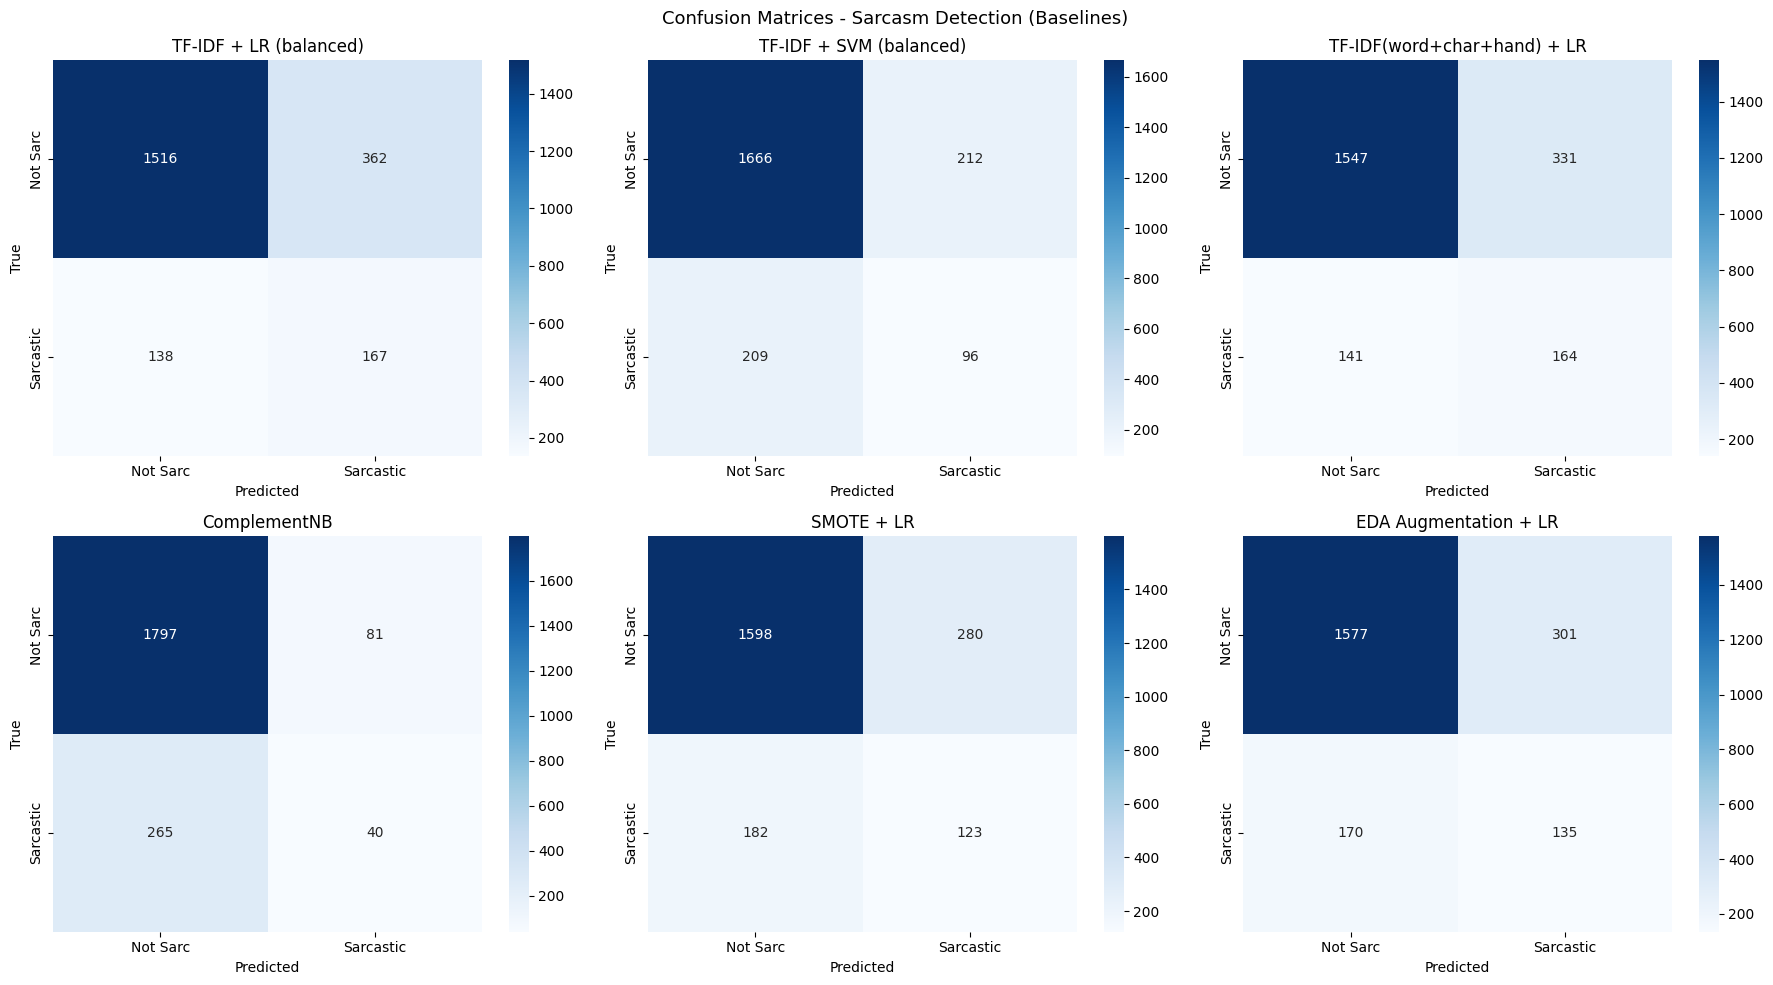

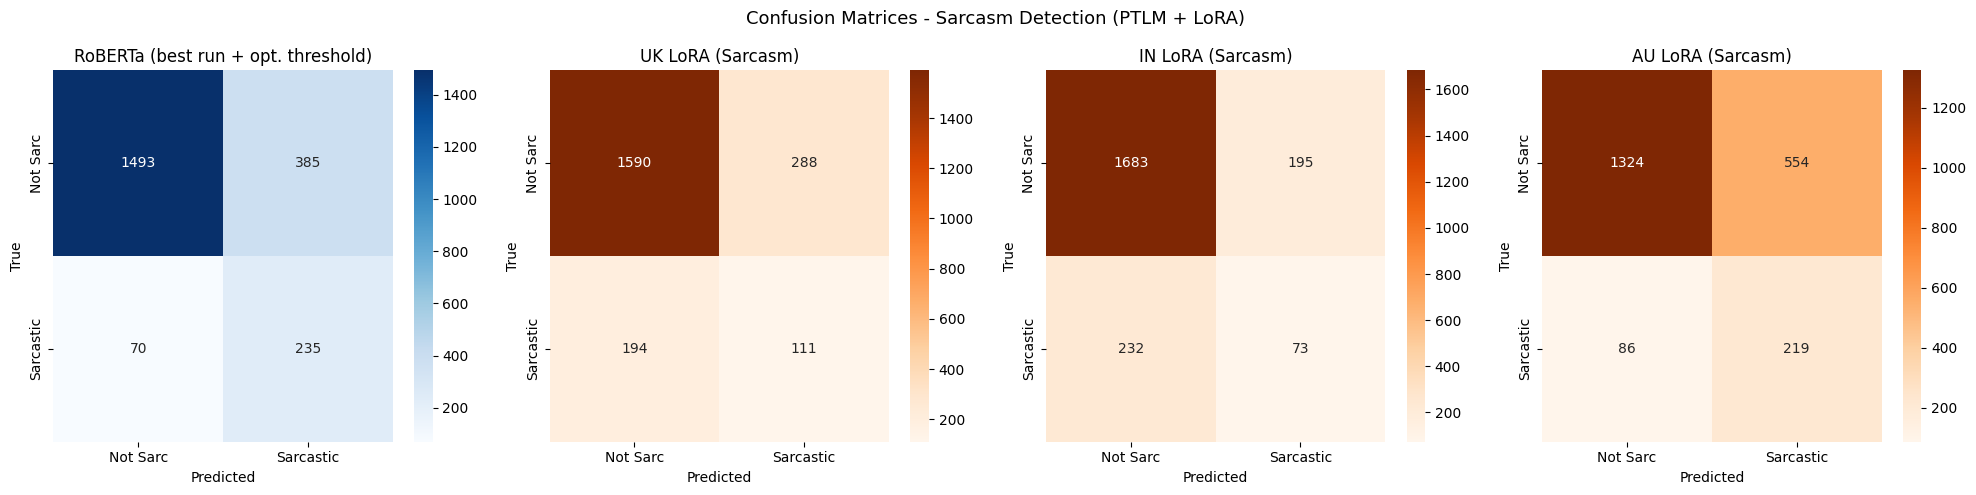

In [16]:
labels = ['Not Sarc', 'Sarcastic']

# --- Figure 1: All 6 baseline confusion matrices (Sarcasm) ---
fig1, axes1 = plt.subplots(2, 3, figsize=(18, 10))
baseline_cms = [
    ('LR',      'TF-IDF + LR (balanced)'),
    ('SVM',     'TF-IDF + SVM (balanced)'),
    ('LR-Comb', 'TF-IDF(word+char+hand) + LR'),
    ('CNB',     'ComplementNB'),
    ('SMOTE',   'SMOTE + LR'),
    ('EDA',     'EDA Augmentation + LR'),
]
for ax, (mname, title) in zip(axes1.flatten(), baseline_cms):
    cm = confusion_matrix(baseline_results['Sarcasm'][mname]['true'],
                          baseline_results['Sarcasm'][mname]['preds'])
    sns.heatmap(cm, annot=True, fmt='d', ax=ax, cmap='Blues',
                xticklabels=labels, yticklabels=labels)
    ax.set_title(title)
    ax.set_ylabel('True')
    ax.set_xlabel('Predicted')

plt.suptitle('Confusion Matrices - Sarcasm Detection (Baselines)', fontsize=13)
plt.tight_layout()
plt.savefig('confusion_matrices_baselines.png', dpi=150)
plt.show()

# --- Figure 2: RoBERTa + all 3 LoRA adapters ---
fig2, axes2 = plt.subplots(1, 4, figsize=(20, 5))

cm_rob = confusion_matrix(all_test[TASK].astype(int).values, rob_preds)
sns.heatmap(cm_rob, annot=True, fmt='d', ax=axes2[0], cmap='Blues',
            xticklabels=labels, yticklabels=labels)
axes2[0].set_title('RoBERTa (best run + opt. threshold)')
axes2[0].set_ylabel('True')
axes2[0].set_xlabel('Predicted')

y_true_sarc = all_test[TASK].astype(int).values
for idx, (name, model) in enumerate([
    ('UK LoRA', model_uk_lora),
    ('IN LoRA', model_in_lora),
    ('AU LoRA', model_au_lora),
]):
    if torch.cuda.is_available():
        model.cuda()
    lora_cm_preds = eval_lora(model, all_test)
    cm = confusion_matrix(y_true_sarc, lora_cm_preds)
    sns.heatmap(cm, annot=True, fmt='d', ax=axes2[idx + 1], cmap='Oranges',
                xticklabels=labels, yticklabels=labels)
    axes2[idx + 1].set_title(f'{name} (Sarcasm)')
    axes2[idx + 1].set_ylabel('True')
    axes2[idx + 1].set_xlabel('Predicted')
    model.cpu()
    gc.collect()
    torch.cuda.empty_cache()

plt.suptitle('Confusion Matrices - Sarcasm Detection (PTLM + LoRA)', fontsize=13)
plt.tight_layout()
plt.savefig('confusion_matrices_ptlm_lora.png', dpi=150)
plt.show()


---
## Section 4: Sarcasm Explanation & Error Analysis

In [17]:
test_in = data['en_IN']['test'].copy().reset_index(drop=True)

if torch.cuda.is_available():
    model_in_lora.cuda()
in_preds = eval_lora(model_in_lora, test_in)
model_in_lora.cpu()
gc.collect()
torch.cuda.empty_cache()

test_in['predicted'] = in_preds
errors = test_in[test_in['predicted'] != test_in['Sarcasm'].astype(int)].reset_index(drop=True)

print(f'Total mispredictions: {len(errors)}')
print()
errors_10 = errors[['text', 'Sarcasm', 'predicted']].head(10)
print(errors_10.to_string())

Total mispredictions: 114

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             

--- Example 1 | true=0 pred=1 ---
Text: Not uneducated but self hating
LIME top features (word → weight):
  uneducated            -0.1105  -----
  Not                   +0.0724  +++
  hating                +0.0680  +++
  but                   +0.0264  +
  self                  +0.0091  



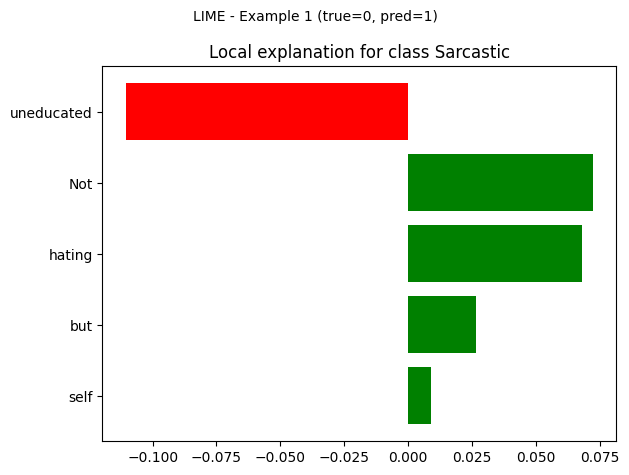

--- Example 2 | true=1 pred=0 ---
Text: parampara pratistha anusaasan by RSS, do the worst to the society and say RAM RAM at the end.
LIME top features (word → weight):
  RAM                   +0.0951  ++++
  society               +0.0553  ++
  at                    -0.0356  -
  pratistha             -0.0276  -
  RSS                   +0.0249  +
  and                   -0.0176  
  the                   +0.0132  
  parampara             +0.0053  
  anusaasan             -0.0046  
  do                    -0.0037  



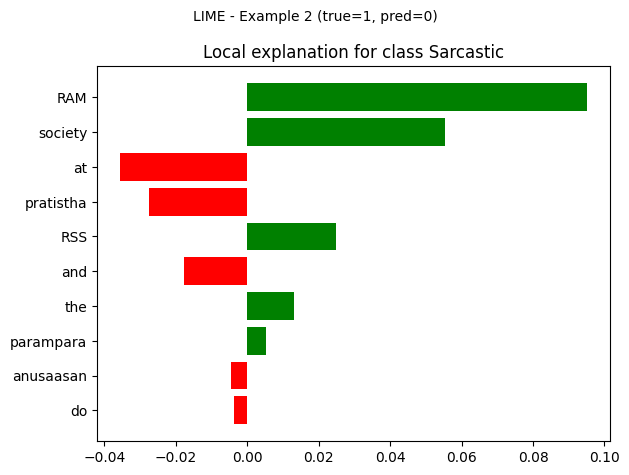

--- Example 3 | true=0 pred=1 ---
Text: # Where's the Tsunami when we need it?
LIME top features (word → weight):
  Tsunami               +0.2430  ++++++++++++
  it                    +0.1160  +++++
  Where                 +0.1086  +++++
  we                    +0.0845  ++++
  s                     +0.0711  +++
  when                  -0.0382  -
  need                  +0.0190  
  the                   +0.0158  



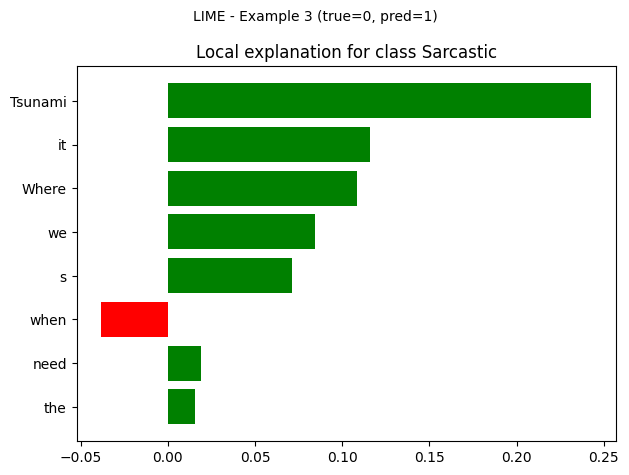

--- Example 4 | true=0 pred=1 ---
Text: The moment the word'Dalit' comes up in a sexual assault case, most of us who dominate the discourse on social media (urb
LIME top features (word → weight):
  dynamics              -0.1144  -----
  We                    +0.0957  ++++
  read                  +0.0871  ++++
  fear                  -0.0792  ---
  outrage               -0.0762  ---
  us                    +0.0669  +++
  comes                 -0.0620  ---
  feel                  +0.0565  ++
  rationalize           +0.0304  +
  upper                 +0.0234  +



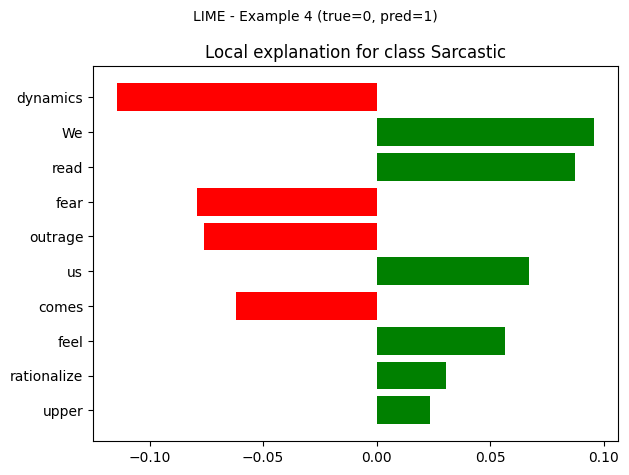

--- Example 5 | true=1 pred=0 ---
Text: Shhhh  "Ashwariya se jalte hai sab". She is an angel she can do nothing wrong.
LIME top features (word → weight):
  wrong                 +0.0550  ++
  Shhhh                 +0.0451  ++
  hai                   +0.0320  +
  Ashwariya             -0.0279  -
  she                   +0.0231  +
  se                    +0.0168  
  nothing               +0.0165  
  do                    -0.0135  
  is                    +0.0111  
  jalte                 +0.0102  



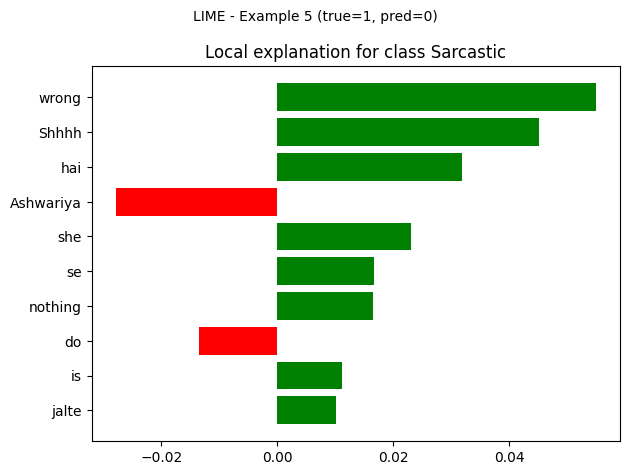

In [18]:
try:
    from lime.lime_text import LimeTextExplainer

    _explainer = LimeTextExplainer(class_names=['Not Sarcastic', 'Sarcastic'])

    # Move IN LoRA model to the correct device for LIME probing
    if torch.cuda.is_available():
        model_in_lora.cuda()
    _lora_in_device = next(model_in_lora.parameters()).device
    model_in_lora.eval()

    def _lora_in_predict_proba(texts):
        probs = []
        for txt in texts:
            enc = tok_lora(txt, truncation=True, max_length=128,
                           padding=True, return_tensors='pt')
            enc = {k: v.to(_lora_in_device) for k, v in enc.items()}
            with torch.no_grad():
                logits = model_in_lora(**enc).logits
            probs.append(torch.softmax(logits, dim=-1).cpu().numpy()[0])
        return np.array(probs)

    n_explain = min(5, len(errors_10))
    for idx in range(n_explain):
        row = errors_10.iloc[idx]
        exp = _explainer.explain_instance(
            row['text'], _lora_in_predict_proba,
            num_features=10, num_samples=200,
        )
        true_lbl = int(row['Sarcasm'])
        pred_lbl = int(row['predicted'])
        print(f'--- Example {idx+1} | true={true_lbl} pred={pred_lbl} ---')
        print(f'Text: {row["text"][:120]}')
        print('LIME top features (word → weight):')
        for word, weight in exp.as_list():
            bar = '+' * int(abs(weight) * 50) if weight > 0 else '-' * int(abs(weight) * 50)
            print(f'  {word:20s}  {weight:+.4f}  {bar}')
        print()
        try:
            fig_lime = exp.as_pyplot_figure()
            fig_lime.suptitle(f'LIME - Example {idx+1} (true={true_lbl}, pred={pred_lbl})', fontsize=10)
            fig_lime.tight_layout()
            fig_lime.savefig(f'lime_example_{idx+1}.png', dpi=120, bbox_inches='tight')
            plt.show()
        except Exception:
            pass

    model_in_lora.cpu()
    gc.collect()
    torch.cuda.empty_cache()

except ImportError:
    print('lime not installed - run: pip install lime')
except NameError as e:
    print(f'Prerequisite missing: {e}')


In [19]:
few_shot_rows = errors_10.iloc[:4]
test_rows     = errors_10.iloc[4:]

def _build_instance_explanation(text, true_label):
    text_l = text.lower()
    excerpt = text[:80].strip()

    positive_words = ['brilliant', 'amazing', 'great', 'excellent', 'wonderful',
                      'perfect', 'angel', 'fantastic', 'love', 'best', 'superb']
    found_positive = [w for w in positive_words if w in text_l]
    has_exclaim  = '!' in text
    has_negation = any(w in text_l for w in ["n't", ' not ', 'never', 'no way', 'hardly'])
    has_codemix  = any(w in text_l for w in [' hai ', ' ka ', ' ki ', ' ke ', ' se ', ' bhi ', ' kya ', ' nahi '])
    has_quotes   = any(ch in text for ch in ['"', '“', '”'])

    if true_label == 1:
        if has_codemix and found_positive:
            return (f'"{excerpt}..." pairs "{found_positive[0]}" with code-mixed Hindi-English phrasing, '
                    f'a pattern often used for ironic distancing in South Asian English.')
        if found_positive and has_negation:
            return (f'"{excerpt}..." puts "{found_positive[0]}" in a negated context. '
                    f'The contradiction between the positive word and the negation is what makes it sarcastic.')
        if found_positive and has_exclaim:
            return (f'"{excerpt}..." uses "{found_positive[0]}" with an exclamation mark. '
                    f'The enthusiasm reads as overblown given the implied situation.')
        if has_quotes:
            return (f'"{excerpt}..." uses quoted speech to create distance from the literal meaning, '
                    f'a common written marker of irony.')
        if found_positive:
            return (f'"{excerpt}..." uses "{found_positive[0]}" in a context where a positive reading '
                    f'does not hold up, which is the source of the sarcasm.')
        return (f'"{excerpt}..." carries sarcasm through tone rather than a single keyword: '
                f'the claim made does not fit what the context implies.')
    else:
        if has_negation:
            return (f'"{excerpt}..." contains negation, but it functions as a factual qualifier '
                    f'rather than rhetorical contrast. The literal reading is the intended one.')
        if found_positive:
            return (f'"{excerpt}..." is a direct positive statement with no contradictory framing. '
                    f'The sentiment expressed matches what the context supports.')
        return (f'"{excerpt}..." is a straightforward claim with no gap between '
                f'what is said and what is meant.')

explanations = [
    _build_instance_explanation(row['text'], int(row['Sarcasm']))
    for _, row in few_shot_rows.iterrows()
]

print('Few-shot examples with instance-specific explanations:')
for (_, row), exp in zip(few_shot_rows.iterrows(), explanations):
    print(f'  Text (true={int(row["Sarcasm"])}): {row["text"][:90]}')
    print(f'  Explanation: {exp}')
    print()

def build_prompt(few_df, exps, input_text):
    prompt = (
        'Task: classify whether the following text is sarcastic.\n'
        'Respond with only 0 (not sarcastic) or 1 (sarcastic).\n\n'
        'Examples:\n'
    )
    for (_, row), exp in zip(few_df.iterrows(), exps):
        prompt += f'Text: {row["text"]}\nExplanation: {exp}\nLabel: {int(row["Sarcasm"])}\n\n'
    prompt += f'Text: {input_text}\nLabel:'
    return prompt

gen = pipeline(
    'text-generation',
    model=LORA_BASE,
    tokenizer=tok_lora,
    max_new_tokens=20,
    device=0 if torch.cuda.is_available() else -1,
    pad_token_id=tok_lora.pad_token_id,
)

print('Few-shot results on remaining 6 mispredictions:')
print()
fs_records = []
for _, row in test_rows.iterrows():
    prompt  = build_prompt(few_shot_rows, explanations, row['text'])
    out     = gen(prompt, truncation=True, max_length=900)[0]['generated_text']
    resp    = out[len(prompt):].strip()
    if resp and resp[0] == '1':
        fs_pred = 1
    elif resp and resp[0] == '0':
        fs_pred = 0
    else:
        fs_pred = -1
    true_label = int(row['Sarcasm'])
    lora_pred  = int(row['predicted'])
    improved   = (true_label == fs_pred) and (true_label != lora_pred)
    fs_records.append({
        'text':      row['text'][:90],
        'true':      true_label,
        'lora_pred': lora_pred,
        'fs_pred':   fs_pred,
        'improved':  improved,
    })
    print(f'Text: {row["text"][:90]}')
    print(f'  True={true_label}  LoRA={lora_pred}  FewShot={fs_pred}  Improved={improved}')
    print()

fs_df = pd.DataFrame(fs_records)
print(f'Improved: {fs_df["improved"].sum()} / {len(fs_df)}')

Few-shot examples with instance-specific explanations:
  Text (true=0): Not uneducated but self hating
  Explanation: "Not uneducated but self hating..." is a straightforward claim with no gap between what is said and what is meant.

  Text (true=1): parampara pratistha anusaasan by RSS, do the worst to the society and say RAM RAM at the e
  Explanation: "parampara pratistha anusaasan by RSS, do the worst to the society and say RAM RA..." carries sarcasm through tone rather than a single keyword: the claim made does not fit what the context implies.

  Text (true=0): # Where's the Tsunami when we need it?
  Explanation: "# Where's the Tsunami when we need it?..." is a straightforward claim with no gap between what is said and what is meant.

  Text (true=0): The moment the word'Dalit' comes up in a sexual assault case, most of us who dominate the 
  Explanation: "The moment the word'Dalit' comes up in a sexual assault case, most of us who dom..." contains negation, but it functions as 

Device set to use cuda:0
Both `max_new_tokens` (=20) and `max_length`(=900) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Few-shot results on remaining 6 mispredictions:



Both `max_new_tokens` (=20) and `max_length`(=900) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Text: Shhhh  "Ashwariya se jalte hai sab". She is an angel she can do nothing wrong.
  True=1  LoRA=0  FewShot=0  Improved=False



Both `max_new_tokens` (=20) and `max_length`(=900) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Text: janhvi  ka cruise party ab Kharab? It's like getting your results when you are attending f
  True=0  LoRA=1  FewShot=1  Improved=False



Both `max_new_tokens` (=20) and `max_length`(=900) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Text: >Especially the neighbouring country.
Indian Muslims support Pakistan is a BJP propoganda.
  True=0  LoRA=1  FewShot=-1  Improved=False



Both `max_new_tokens` (=20) and `max_length`(=900) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Text: My boi writing scripts
  True=1  LoRA=0  FewShot=1  Improved=True



Both `max_new_tokens` (=20) and `max_length`(=900) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Text: His first book  - indian war of independence was banned by the British even before he coul
  True=0  LoRA=1  FewShot=1  Improved=False

Text: People who watch IPL, Cricket and those who like to follow this sort of content.
  True=0  LoRA=1  FewShot=1  Improved=False

Improved: 1 / 6


---
## Section 5: Deployment

### 5.1 Deployment Endpoint



In [20]:
import threading
from flask import Flask, request, jsonify, render_template_string

try:
    gen.model.cpu()
    del gen
except NameError:
    pass
gc.collect()
torch.cuda.empty_cache()

_use_cuda = torch.cuda.is_available()

VARIETY_MAP = {
    'en-UK': (model_uk_lora, tok_lora),
    'en-IN': (model_in_lora, tok_lora),
    'en-AU': (model_au_lora, tok_lora),
}

for _m, _ in VARIETY_MAP.values():
    _m.cpu().eval()
    if not _use_cuda:
        _m.float()

_active_variety = [None]
if _use_cuda:
    model_uk_lora.cuda()
    _active_variety[0] = 'en-UK'

def predict(text, variety, task):
    if not text.strip():
        return 'Enter some text.'
    model, tok = VARIETY_MAP[variety]
    if _use_cuda and _active_variety[0] != variety:
        if _active_variety[0] is not None:
            VARIETY_MAP[_active_variety[0]][0].cpu()
            torch.cuda.empty_cache()
        model.cuda()
        _active_variety[0] = variety
    device = next(model.parameters()).device
    enc = tok(text, return_tensors='pt', truncation=True, max_length=128, padding=True)
    enc = {k: v.to(device) for k, v in enc.items()}
    with torch.no_grad():
        pred = torch.argmax(model(**enc).logits, dim=-1).item()
    if task == 'Sarcasm':
        return 'Sarcastic' if pred == 1 else 'Not Sarcastic'
    return 'Positive' if pred == 1 else 'Negative'

app = Flask(__name__)

HTML = """
<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8">
<meta name="viewport" content="width=device-width, initial-scale=1.0">
<title>BESSTIE Classifier</title>
<style>
  body { font-family: Arial, sans-serif; max-width: 650px; margin: 60px auto; padding: 0 20px; background: #f5f5f5; }
  h1   { color: #333; }
  p.sub { color: #666; margin-top: -10px; }
  label { display: block; margin-top: 16px; font-weight: bold; color: #444; }
  textarea, select {
    width: 100%; padding: 10px; margin-top: 6px; border: 1px solid #ccc;
    border-radius: 6px; font-size: 14px; box-sizing: border-box;
  }
  textarea { height: 100px; resize: vertical; }
  button {
    margin-top: 20px; padding: 12px 28px; background: #4a90d9; color: #fff;
    border: none; border-radius: 6px; font-size: 15px; cursor: pointer;
  }
  button:hover { background: #357abd; }
  #result-box {
    margin-top: 24px; padding: 16px; background: #fff; border-radius: 8px;
    border-left: 5px solid #4a90d9; font-size: 16px; display: none;
  }
  #spinner { display: none; margin-top: 14px; color: #888; }
</style>
</head>
<body>
<h1>BESSTIE Classifier</h1>
<p class="sub">Sentiment &amp; sarcasm detection across British, Indian, and Australian English.</p>

<label for="text">Input Text</label>
<textarea id="text" placeholder="Type or paste text here…"></textarea>

<label for="variety">English Variety</label>
<select id="variety">
  <option value="en-UK">en-UK (British)</option>
  <option value="en-IN">en-IN (Indian)</option>
  <option value="en-AU">en-AU (Australian)</option>
</select>

<label for="task">Task</label>
<select id="task">
  <option value="Sarcasm">Sarcasm</option>
  <option value="Sentiment">Sentiment</option>
</select>

<br>
<button onclick="run()">Classify</button>
<div id="spinner">Running…</div>
<div id="result-box"></div>

<script>
async function run() {
  const text    = document.getElementById('text').value;
  const variety = document.getElementById('variety').value;
  const task    = document.getElementById('task').value;
  const box     = document.getElementById('result-box');
  const spin    = document.getElementById('spinner');
  box.style.display  = 'none';
  spin.style.display = 'block';
  const resp = await fetch('/predict', {
    method: 'POST',
    headers: { 'Content-Type': 'application/json' },
    body: JSON.stringify({ text, variety, task }),
  });
  const data = await resp.json();
  spin.style.display = 'none';
  box.style.display  = 'block';
  box.textContent    = 'Prediction: ' + data.result;
}
</script>
</body>
</html>
"""

@app.route('/')
def index():
    return render_template_string(HTML)

@app.route('/predict', methods=['POST'])
def predict_route():
    body   = request.get_json(force=True)
    result = predict(body.get('text', ''), body.get('variety', 'en-UK'), body.get('task', 'Sarcasm'))
    return jsonify({'result': result})

PORT = 5000
server_thread = threading.Thread(
    target=lambda: app.run(host='0.0.0.0', port=PORT, use_reloader=False, threaded=False),
    daemon=True,
)
server_thread.start()
print(f"Classifier running at http://localhost:{PORT}")
print("All three varieties served by fine-tuned LoRA adapters (UK, IN, AU).")

Classifier running at http://localhost:5000
All three varieties served by fine-tuned LoRA adapters (UK, IN, AU).


 * Serving Flask app '__main__'
 * Debug mode: off


 * Running on all addresses (0.0.0.0)
 * Running on http://127.0.0.1:5000
 * Running on http://192.168.0.218:5000
Press CTRL+C to quit


### 5.2 Efficiency

In [21]:
sample_single = 'Absolutely brilliant service, only took four hours.'
sample_batch  = [sample_single] * 100

X_single = tfidf.transform([sample_single])
X_batch  = tfidf.transform(sample_batch)

times_lr = []
for _ in range(200):
    t0 = time.perf_counter()
    lr_sarc.predict(X_single)
    times_lr.append((time.perf_counter() - t0) * 1000)

t0 = time.perf_counter()
lr_sarc.predict(X_batch)
lr_batch_ms = (time.perf_counter() - t0) * 1000

print(f'TF-IDF + LR  single (avg 200 runs): {np.mean(times_lr):.3f} ms')
print(f'TF-IDF + LR  batch=100:             {lr_batch_ms:.2f} ms')

model_rob.eval()
device = next(model_rob.parameters()).device
enc_s = tok_rob(sample_single, return_tensors='pt', truncation=True,
                max_length=128, padding=True)
enc_s = {k: v.to(device) for k, v in enc_s.items()}

times_rob = []
with torch.no_grad():
    for _ in range(50):
        t0 = time.perf_counter()
        model_rob(**enc_s)
        times_rob.append((time.perf_counter() - t0) * 1000)

enc_b = tok_rob(sample_batch, return_tensors='pt', truncation=True,
                max_length=128, padding=True)
enc_b = {k: v.to(device) for k, v in enc_b.items()}
with torch.no_grad():
    t0 = time.perf_counter()
    model_rob(**enc_b)
    rob_batch_ms = (time.perf_counter() - t0) * 1000

print(f'RoBERTa      single (avg 50 runs):  {np.mean(times_rob):.2f} ms')
print(f'RoBERTa      batch=100:             {rob_batch_ms:.2f} ms')

lora_bench_model = model_uk_lora
if torch.cuda.is_available():
    lora_bench_model.cuda()
lora_bench_model.eval()
lora_device = next(lora_bench_model.parameters()).device

enc_sl = tok_lora(sample_single, return_tensors='pt', truncation=True,
                  max_length=128, padding=True)
enc_sl = {k: v.to(lora_device) for k, v in enc_sl.items()}

times_lora = []
with torch.no_grad():
    for _ in range(50):
        t0 = time.perf_counter()
        lora_bench_model(**enc_sl)
        times_lora.append((time.perf_counter() - t0) * 1000)

enc_bl = tok_lora(sample_batch, return_tensors='pt', truncation=True,
                  max_length=128, padding=True)
enc_bl = {k: v.to(lora_device) for k, v in enc_bl.items()}
with torch.no_grad():
    t0 = time.perf_counter()
    lora_bench_model(**enc_bl)
    lora_batch_ms = (time.perf_counter() - t0) * 1000

print(f'LoRA (UK)    single (avg 50 runs):  {np.mean(times_lora):.2f} ms')
print(f'LoRA (UK)    batch=100:             {lora_batch_ms:.2f} ms')

lora_bench_model.cpu()
gc.collect()
torch.cuda.empty_cache()


TF-IDF + LR  single (avg 200 runs): 0.301 ms
TF-IDF + LR  batch=100:             0.64 ms
RoBERTa      single (avg 50 runs):  131.85 ms
RoBERTa      batch=100:             2037.06 ms
LoRA (UK)    single (avg 50 runs):  43.63 ms
LoRA (UK)    batch=100:             100.70 ms
